## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sps
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from Challenge.paths import load_holdout_split
from Challenge.utils import split_into_folds, train_all_models

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
RANDOM_SEED = 0xbabe

URM_inner, URM_outer, = load_holdout_split()
folds_10 = split_into_folds(URM_inner, 10, random_seed=RANDOM_SEED)

Fold 1/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446
URM_train: 2191001
URM_validation: 243445
------------------------------
Fold 2/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446
URM_train: 2191001
URM_validation: 243445
------------------------------
Fold 3/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446
URM_train: 2191001
URM_validation: 243445
------------------------------
Fold 4/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446
URM_train: 2191001
URM_validation: 243445
------------------------------
Fold 5/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446
URM_train: 2191001
URM_validation: 243445
------------------------------
Fold 6/10
URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 2434446

## **Models**

In [5]:
from Recommenders.NonPersonalizedRecommender import TopPop
from Recommenders.KNN.UserKNNCFRecommender import UserKNNCFRecommender
from Recommenders.KNN.ItemKNNCFRecommender import ItemKNNCFRecommender
from Recommenders.GraphBased.P3alphaRecommender import P3alphaRecommender
from Recommenders.GraphBased.RP3betaRecommender import RP3betaRecommender
from Recommenders.EASE_R.EASE_R_Recommender import EASE_R_Recommender
from Recommenders.SLIM.SLIMElasticNetRecommender import MultiThreadSLIM_SLIMElasticNetRecommender
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_WARP_Cython
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_BPR_Cython
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_SVDpp_Cython

from Recommenders.SLIM.Cython.SLIM_BPR_Cython import SLIM_BPR_Cython
from implicit.cpu.als import AlternatingLeastSquares
from Recommenders.MatrixFactorization.NMFRecommender import NMFRecommender
from Recommenders.Neural.MultVAE_PyTorch_Recommender import MultVAERecommender_PyTorch_OptimizerMask

In [6]:
models_mapping = {
    'TopPop': TopPop,
    'ItemKNN_cosine': ItemKNNCFRecommender,
    'ItemKNN_jaccard': ItemKNNCFRecommender,
    'ItemKNN_asymmetric': ItemKNNCFRecommender,
    'ItemKNN_tversky': ItemKNNCFRecommender,
    'ItemKNN_dice': ItemKNNCFRecommender,
    'UserKNN_cosine': UserKNNCFRecommender,
    'UserKNN_jaccard': UserKNNCFRecommender,
    'UserKNN_asymmetric': UserKNNCFRecommender,
    'UserKNN_tversky': UserKNNCFRecommender,
    'UserKNN_dice': UserKNNCFRecommender,
    'EASE_R': EASE_R_Recommender,
    'P3alpha': P3alphaRecommender,
    'RP3beta': RP3betaRecommender,
    'IALS': AlternatingLeastSquares,
    'MatrixFactorization_WARP': MatrixFactorization_WARP_Cython,
    'MatrixFactorization_BPR': MatrixFactorization_BPR_Cython,
    'MatrixFactorization_SVDpp': MatrixFactorization_SVDpp_Cython,
    
    'SLIM_BPR': SLIM_BPR_Cython,
    'NMF': NMFRecommender,
    'MultVAE': MultVAERecommender_PyTorch_OptimizerMask,
    'SLIMElasticNet': MultiThreadSLIM_SLIMElasticNetRecommender
}

# Unused models
del models_mapping['MatrixFactorization_SVDpp']
del models_mapping['SLIM_BPR']

# Too slow to train all folds
del models_mapping['MatrixFactorization_BPR']
del models_mapping['NMF']

# Remove EASE_R
del models_mapping['EASE_R'] # Conflict with parallel training

In [7]:
models_mapping

{'TopPop': Recommenders.NonPersonalizedRecommender.TopPop,
 'ItemKNN_cosine': Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender,
 'ItemKNN_jaccard': Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender,
 'ItemKNN_asymmetric': Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender,
 'ItemKNN_tversky': Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender,
 'ItemKNN_dice': Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender,
 'UserKNN_cosine': Recommenders.KNN.UserKNNCFRecommender.UserKNNCFRecommender,
 'UserKNN_jaccard': Recommenders.KNN.UserKNNCFRecommender.UserKNNCFRecommender,
 'UserKNN_asymmetric': Recommenders.KNN.UserKNNCFRecommender.UserKNNCFRecommender,
 'UserKNN_tversky': Recommenders.KNN.UserKNNCFRecommender.UserKNNCFRecommender,
 'UserKNN_dice': Recommenders.KNN.UserKNNCFRecommender.UserKNNCFRecommender,
 'P3alpha': Recommenders.GraphBased.P3alphaRecommender.P3alphaRecommender,
 'RP3beta': Recommenders.GraphBased.RP3betaRecommender.RP3betaRecomm

## **Greedy Gain/Cost Function**

In [8]:
def greedy_candidate_selection(recs_cache, model_names, folds, cutoffs, budget):
    """
    recs_cache: List of dictionaries (one per fold). 
                recs_cache[0]['ALS'] is the prediction matrix for Fold 0.
    folds: List of tuples (URM_train, URM_val)
    """
    n_users, n_items = folds[0][0].shape
    
    # --- FIX 1: Create a mask list, one for each fold ---
    # We treat each fold as a parallel universe.
    current_candidates_masks = [
        sps.csr_matrix((n_users, n_items), dtype=bool) 
        for _ in range(len(folds))
    ]

    # Pre-calculate boolean validation matrices
    URM_val_bool = [fold[1].astype(bool) for fold in folds]
    # Pre-calculate ground truth counts for recall calculation
    URM_val_nnz = [u.getnnz() for u in URM_val_bool]

    selected_cutoffs = {name: 0 for name in model_names}
    avg_candidate_count = 0
    
    # Track accumulated hits (numerator for recall) per fold
    total_hits_per_fold = [0 for _ in folds]

    # History for plotting
    history = {
        'candidates': [],
        'recall': [],
        'ratios': [],
        'cutoffs': []
    }

    while avg_candidate_count < budget:
        best_step_info = None  # Stores: (model, cutoff, specific_masks, specific_gains, specific_costs)
        best_global_ratio = -1

        for model_name in model_names:
            current_cutoff = selected_cutoffs[model_name]
            
            # Smart Horizon: Look only 3 steps ahead
            future_cutoffs = [c for c in cutoffs if c > current_cutoff][:3]

            for next_cutoff in future_cutoffs:
                
                fold_gains = []
                fold_costs = []
                fold_new_masks = []

                # --- Iterate over Folds ---
                for fold_idx in range(len(folds)):
                    # Get the predictions for this specific fold
                    model_recs = recs_cache[fold_idx][model_name]
                    
                    # Slice the NEW recommendations (incremental step)
                    # e.g. from index 10 to 20
                    new_recs_slice = model_recs[:, current_cutoff:next_cutoff]

                    # Flatten to create sparse proposal matrix
                    # (This is the most expensive part, but necessary)
                    rows = np.repeat(np.arange(n_users), new_recs_slice.shape[1])
                    cols = new_recs_slice.flatten()
                    
                    # Create sparse boolean matrix of PROPOSED items
                    # data=True is default for boolean, but explicit is safer
                    proposal_mask = sps.csr_matrix(
                        (np.ones(len(cols), dtype=bool), (rows, cols)), 
                        shape=(n_users, n_items),
                        dtype=bool
                    )

                    # --- SET DIFFERENCE LOGIC ---
                    # New = Proposal AND (NOT Current)
                    # In boolean sparse logic: (Proposal > Current) works perfectly
                    new_items_mask = (proposal_mask > current_candidates_masks[fold_idx])
                    
                    marginal_cost = new_items_mask.nnz
                    
                    if marginal_cost == 0:
                        fold_gains.append(0)
                        fold_costs.append(0)
                        fold_new_masks.append(None)
                        continue

                    # Calculate Hits (Intersection with Validation)
                    hits_mask = new_items_mask.multiply(URM_val_bool[fold_idx])
                    marginal_gain = hits_mask.nnz
                    
                    fold_gains.append(marginal_gain)
                    fold_costs.append(marginal_cost)
                    fold_new_masks.append(new_items_mask)

                # --- Aggregation across folds ---
                avg_gain = np.mean(fold_gains)
                avg_cost = np.mean(fold_costs)
                
                if avg_cost == 0:
                    continue
                
                ratio = avg_gain / avg_cost

                if ratio > best_global_ratio:
                    best_global_ratio = ratio
                    # We store the specific masks/gains so we don't have to recompute them
                    best_step_info = (model_name, next_cutoff, fold_new_masks, fold_gains, fold_costs)

        # --- UPDATE STEP ---
        if best_step_info is None:
            print("Convergence reached (no more positive gain steps).")
            break

        b_model, b_cutoff, b_masks, b_gains, b_costs = best_step_info
        
        # Update Cutoffs
        selected_cutoffs[b_model] = b_cutoff
        
        current_total_candidates = 0
        current_total_recall = 0

        for fold_idx in range(len(folds)):
            if b_masks[fold_idx] is not None:
                # Update the mask for this fold
                current_candidates_masks[fold_idx] += b_masks[fold_idx]
                
                # Update hits
                total_hits_per_fold[fold_idx] += b_gains[fold_idx]

            # Calculate stats for this fold
            n_candidates_fold = current_candidates_masks[fold_idx].nnz
            recall_fold = total_hits_per_fold[fold_idx] / URM_val_nnz[fold_idx]

            current_total_candidates += (n_candidates_fold / n_users)
            current_total_recall += recall_fold

        # Average across folds
        avg_candidate_count = current_total_candidates / len(folds)
        avg_recall = current_total_recall / len(folds)

        # Log
        history['candidates'].append(avg_candidate_count)
        history['recall'].append(avg_recall)
        history['ratios'].append(best_global_ratio)
        history['cutoffs'].append((b_model, b_cutoff))

        print(f"Selected {b_model} @ {b_cutoff}. "
              f"Ratio: {best_global_ratio:.5f}. "
              f"Avg Cand: {avg_candidate_count:.2f}. "
              f"Avg Recall: {avg_recall:.5f}")

    print("Final Selection:", selected_cutoffs)
    return selected_cutoffs, history

## **Visualization functions**

In [9]:
def plot_candidate_selection_results(history, selected_cutoffs, title="Candidate Selection Optimization"):
    """
    Visualizes the training process of the Greedy Selection algorithm.
    
    Args:
        history (dict): Dictionary containing 'candidates', 'recall', 'ratios' lists.
        selected_cutoffs (dict): Final dictionary {model_name: cutoff}.
        title (str): Main title for the dashboard.
    """
    # Set style for professional look
    sns.set_theme(style="whitegrid")
    
    # Create a figure with a layout: 
    # Top Left: Recall vs Candidates (Pareto)
    # Top Right: Marginal Ratio (Diminishing Returns)
    # Bottom: Final Composition Bar Chart
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    # -------------------------------------------------------
    # PLOT 1: Pareto Frontier (Recall vs Candidates)
    # -------------------------------------------------------
    candidates = history['candidates']
    recall = history['recall']
    
    # Plot the line
    ax1.plot(candidates, recall, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=5)
    
    # Highlight the final point
    ax1.scatter(candidates[-1], recall[-1], color='#e74c3c', s=100, zorder=5, label='Final Selection')
    
    ax1.set_title("Pareto Frontier: Recall vs. List Length", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Average Number of Candidates per User")
    ax1.set_ylabel("MAP / Recall (Validation)")
    ax1.legend()
    
    # Add grid text to show "Diminishing Returns" area
    if len(candidates) > 2:
        mid_idx = len(candidates) // 2
        ax1.annotate('Diminishing Returns\nStart Here?', 
                     xy=(candidates[mid_idx], recall[mid_idx]), 
                     xytext=(candidates[mid_idx]+10, recall[mid_idx]-0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05))

    # -------------------------------------------------------
    # PLOT 2: Marginal Ratio Evolution
    # -------------------------------------------------------
    ratios = history['ratios']
    steps = range(1, len(ratios) + 1)
    
    ax2.plot(steps, ratios, color='#27ae60', linewidth=2, linestyle='--')
    ax2.fill_between(steps, ratios, color='#27ae60', alpha=0.1)
    
    ax2.set_title("Marginal Utility (Gain per Candidate Added)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Optimization Step")
    ax2.set_ylabel("Marginal Ratio (Gain / Cost)")
    ax2.set_yscale("log") # Log scale often helps see the drop better
    
    # -------------------------------------------------------
    # PLOT 3: Final Model Composition
    # -------------------------------------------------------
    models = list(selected_cutoffs.keys())
    cutoffs = list(selected_cutoffs.values())
    
    # Sort for better visualization
    sorted_indices = np.argsort(cutoffs)[::-1]
    models = [models[i] for i in sorted_indices]
    cutoffs = [cutoffs[i] for i in sorted_indices]
    
    colors = sns.color_palette("viridis", len(models))
    bars = ax3.bar(models, cutoffs, color=colors)
    
    ax3.set_title("Final Candidate Composition (Cutoffs)", fontsize=14, fontweight='bold')
    ax3.set_xlabel("Recommender Model")
    ax3.set_ylabel("Top-K Cutoff Selected")
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

In [10]:
def analyze_candidate_redundancy(recs_cache, selected_cutoffs, folds):
    """
    Analyzes the unique contribution of each model in the final ensemble.
    Sorts models by cutoff size (Descending) to see if small models are redundant.
    """
    # 1. Sort models by Cutoff (Largest first)
    # We want to see if the 'Big' models cover the 'Small' models
    sorted_models = sorted(
        [(k, v) for k, v in selected_cutoffs.items() if v > 0],
        key=lambda x: x[1],
        reverse=True
    )
    
    model_names = [x[0] for x in sorted_models]
    cutoffs = [x[1] for x in sorted_models]
    
    n_users = folds[0][0].shape[0]
    n_items = folds[0][0].shape[1]
    
    # Store results per fold to average later
    stats_per_fold = []

    for fold_idx, (_, URM_val) in enumerate(folds):
        URM_val_bool = URM_val.astype(bool)
        
        # Track what we have found so far (Union of previous models)
        accumulated_hits_mask = sps.csr_matrix((n_users, n_items), dtype=bool)
        
        fold_stats = []
        
        for model_name, cutoff in sorted_models:
            # Get recommendations for this model/fold
            recs = recs_cache[fold_idx][model_name][:, :cutoff]
            
            # Create Sparse Mask of Recommendations
            rows = np.repeat(np.arange(n_users), recs.shape[1])
            cols = recs.flatten()
            recs_mask = sps.csr_matrix(
                (np.ones(len(cols), dtype=bool), (rows, cols)), 
                shape=(n_users, n_items), dtype=bool
            )
            
            # 1. Identify ALL Hits (Correct Recommendations)
            # Intersection between Recommendations AND Ground Truth
            all_hits_mask = recs_mask.multiply(URM_val_bool)
            total_hits = all_hits_mask.nnz
            
            # 2. Identify UNIQUE Hits (Not found by previous models)
            # (Current Hits) > (Accumulated Hits)
            # This keeps only hits that are in Current but NOT in Accumulated
            unique_hits_mask = (all_hits_mask > accumulated_hits_mask)
            unique_hits = unique_hits_mask.nnz
            
            # 3. Update Accumulated Hits
            accumulated_hits_mask += all_hits_mask
            
            fold_stats.append({
                'Model': model_name,
                'Cutoff': cutoff,
                'Total_Hits': total_hits,
                'Unique_Hits': unique_hits,
                'Redundant_Hits': total_hits - unique_hits
            })
            
        stats_per_fold.append(pd.DataFrame(fold_stats))

    # Average across folds
    avg_stats = pd.concat(stats_per_fold).groupby(['Model', 'Cutoff']).mean().reset_index()
    
    # Re-sort to match the processing order (Descending Cutoff)
    avg_stats = avg_stats.set_index('Model').loc[model_names].reset_index()
    
    return avg_stats

def plot_redundancy(df_results):
    sns.set_theme(style="whitegrid")
    
    # Calculate percentage of contribution that is unique
    df_results['Unique_Pct'] = df_results['Unique_Hits'] / df_results['Total_Hits']
    
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Create Stacked Bar Chart
    # Bottom bar: Unique Hits (Green)
    sns.barplot(data=df_results, x='Model', y='Total_Hits', color='lightgray', label='Redundant Hits', ax=ax1)
    
    # Top overlay: Redundant Hits (Gray) -> Actually we plot Unique on top to show proportion?
    # Better approach: Plot Total in Gray, then plot Unique in Green on top.
    sns.barplot(data=df_results, x='Model', y='Unique_Hits', color='#2ecc71', label='Unique Contribution', ax=ax1)
    
    # Formatting
    ax1.set_title("Model Consolidation Analysis: Unique vs. Redundant Hits", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Number of Correct Hits (Recall)", fontsize=12)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.legend()
    
    # Add text labels
    for i, row in df_results.iterrows():
        # Label the Unique %
        ax1.text(i, row['Unique_Hits'] + (row['Total_Hits']*0.01), 
                 f"{row['Unique_Pct']:.0%}", 
                 ha='center', color='black', fontweight='bold', fontsize=10)
        
        # Label the Cutoff
        ax1.text(i, row['Total_Hits'] / 2, 
                 f"@{row['Cutoff']}", 
                 ha='center', color='white', alpha=0.7, fontsize=9)

    plt.tight_layout()
    plt.show()

In [11]:
def analyze_candidate_noise(recs_cache, selected_cutoffs, folds):
    """
    Analyzes the Signal-to-Noise ratio of each model.
    """
    model_names = [k for k, v in selected_cutoffs.items() if v > 0]
    n_users = folds[0][0].shape[0]
    
    stats_per_fold = []

    for fold_idx, (_, URM_val) in enumerate(folds):
        URM_val_bool = URM_val.astype(bool)
        fold_stats = []
        
        for model_name in model_names:
            cutoff = selected_cutoffs[model_name]
            recs = recs_cache[fold_idx][model_name][:, :cutoff]
            
            # Count Total Recommendations (Candidates)
            total_recommendations = n_users * cutoff
            
            # Count Hits (Signal)
            rows = np.repeat(np.arange(n_users), recs.shape[1])
            cols = recs.flatten()
            recs_mask = sps.csr_matrix(
                (np.ones(len(cols), dtype=bool), (rows, cols)), 
                shape=(n_users, folds[0][0].shape[1]), dtype=bool
            )
            hits = recs_mask.multiply(URM_val_bool).nnz
            
            # Calculate Noise
            noise = total_recommendations - hits
            
            fold_stats.append({
                'Model': model_name,
                'Cutoff': cutoff,
                'Total_Recs': total_recommendations,
                'Hits': hits,
                'Noise': noise,
                'Precision': hits / total_recommendations
            })
            
        stats_per_fold.append(pd.DataFrame(fold_stats))

    avg_stats = pd.concat(stats_per_fold).groupby('Model').mean().reset_index()
    # Sort by Precision (Highest quality first)
    avg_stats = avg_stats.sort_values('Precision', ascending=False)
    
    return avg_stats

def plot_noise_analysis(df_noise):
    sns.set_theme(style="whitegrid")
    
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Stacked Bar Chart: Total Recs = Noise + Hits
    # Plot Total (which will represent Noise because Hits are smaller) in Red
    sns.barplot(data=df_noise, x='Model', y='Total_Recs', color='#e74c3c', label='Noise (False Positives)', ax=ax1)
    
    # Plot Hits on top (technically bottom of the stack) in Green
    sns.barplot(data=df_noise, x='Model', y='Hits', color='#2ecc71', label='Signal (True Positives)', ax=ax1)
    
    ax1.set_title("Signal-to-Noise Ratio: Precision Analysis", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Total Generated Candidates", fontsize=12)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.legend()
    
    # Add Precision labels
    for i, row in df_noise.reset_index().iterrows():
        # Label Precision % at the bottom (green part)
        ax1.text(i, row['Hits'] + (row['Total_Recs']*0.01), 
                 f"{row['Precision']:.2%}", 
                 ha='center', color='black', fontweight='bold', fontsize=10)
        
        # Label Cutoff at the top
        ax1.text(i, row['Total_Recs'], 
                 f"@{int(row['Cutoff'])}", 
                 ha='center', va='bottom', color='black', fontsize=9)

    plt.tight_layout()
    plt.show()

In [12]:
def reconstruct_cutoffs(history, target_candidates=None, target_step=None):
    """
    Reconstructs the model configuration (cutoffs) at a specific point in the past.
    
    Args:
        history (dict): The dictionary returned by greedy_candidate_selection.
                        Must contain 'cutoffs' and 'candidates' lists.
        target_candidates (int/float): Stop as soon as average candidates >= this value.
        target_step (int): Stop after this many optimization steps (0-indexed).
        
    Returns:
        dict: A dictionary {model_name: cutoff} representing the state at that moment.
    """
    # 1. Initialize all models found in the history to 0
    # We scan the entire history first to know which models exist
    all_models = set([update[0] for update in history['cutoffs']])
    reconstructed_cutoffs = {model: 0 for model in all_models}
    
    # 2. Determine the replay limit
    limit_index = len(history['cutoffs']) # Default: replay everything
    
    if target_step is not None:
        # User wants a specific step (e.g., Step 10)
        limit_index = target_step + 1
        print(f"Replaying history up to Step {target_step}...")
        
    elif target_candidates is not None:
        # User wants a specific budget (e.g., 50 candidates)
        # Find the first step where candidates >= target
        for i, count in enumerate(history['candidates']):
            if count >= target_candidates:
                limit_index = i + 1
                print(f"Target of {target_candidates} candidates reached at Step {i} "
                      f"(Actual: {count:.2f}).")
                break
        else:
            print(f"Warning: Target {target_candidates} was never reached. "
                  f"Max was {history['candidates'][-1]:.2f}. Returning full history.")
    
    # 3. Replay the history
    # history['cutoffs'] is a list of tuples: (model_name, new_cutoff_value)
    steps_to_replay = history['cutoffs'][:limit_index]
    
    for model_name, new_cutoff in steps_to_replay:
        reconstructed_cutoffs[model_name] = new_cutoff
        
    return reconstructed_cutoffs

## **Candidate Selection**

In [ ]:
budget = 150
cutoffs = [
    5, 10, 15, 20, 25, 30, 40, 50,    # High precision area
    60, 70, 75, 80, 85, 90, 95, 100,  # Granular "Sweet Spot" tuning
    110, 120, 130, 140, 150           # Extended range
]
max_cutoff = max(cutoffs)

### **Cache predictions**

In [14]:
# Pre-compute recommendations for all models and folds
user_ids = np.arange(folds_10[0][0].shape[0])
recs_cache_folds = [{} for _ in folds_10]
model_names = list(models_mapping.keys()) + ['EASE_R']

In [15]:
for fold_index, (URM_train, _) in enumerate(folds_10):
    name, model = train_all_models(URM_train, {'EASE_R': EASE_R_Recommender})[0]

    print(f"Precomputing recommendations for {name}...")
    recommended_items = model.recommend(user_ids, cutoff=max_cutoff)
    recs_cache_folds[fold_index][name] = np.array(recommended_items)

# Free memory
del model
gc.collect()

  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 7.78 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 8.54 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 7.25 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 8.02 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 8.19 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 7.39 sec
Precomputing recommendations for EASE_R...
  Training model: EASE_R
EASE_R_Recommen

6

In [16]:
recs_cache_folds

[{'EASE_R': array([[4486, 2399, 2628, ...,  275, 1015, 4029],
         [3142, 6810, 5474, ..., 5445, 2456,  276],
         [4264, 5640, 2557, ...,  101, 1328, 5504],
         ...,
         [2907, 3125, 3516, ..., 1032, 3326, 1535],
         [4727, 4071, 1196, ..., 4378, 3907,  227],
         [5489,  596, 4169, ...,  896, 2415, 4129]], shape=(27095, 150))},
 {'EASE_R': array([[4264, 4486, 5532, ..., 2587, 6930, 3317],
         [6165, 6810, 3142, ..., 1656, 1690, 4427],
         [4264, 4023, 2557, ..., 4749, 4217, 5465],
         ...,
         [2907, 3142, 3516, ..., 5882, 1217, 4533],
         [4071, 1940, 1196, ..., 4478, 3873, 2438],
         [5489, 3666,  283, ...,  347, 5710, 6101]], shape=(27095, 150))},
 {'EASE_R': array([[3875, 4264, 2226, ..., 1528, 3052, 3526],
         [3142,  755, 6810, ..., 2472, 3346,  291],
         [4264, 2557, 4709, ..., 4154, 6551, 2744],
         ...,
         [2907, 3142, 3516, ..., 4427, 5269, 5891],
         [1196, 1373, 4709, ..., 4190, 4154, 3379]

In [17]:
def get_user_batches(user_ids, batch_size=1000):
    for i in range(0, len(user_ids), batch_size):
        yield user_ids[i:i + batch_size]

In [18]:
for fold_index, (URM_train, _) in enumerate(folds_10):
    print(f"Training fold {fold_index+1}/10")
    trained_models = train_all_models(URM_train, models_mapping)
    
    for model_name, model in trained_models:
        print(f"Precomputing recommendations for {model_name}...")
        model_names.append(model_name)

        if type(model) == AlternatingLeastSquares:
            recommended_items, scores = model.recommend(
                user_ids, 
                URM_train, 
                N=max_cutoff, 
                filter_already_liked_items=True
            )

        elif type(model) == MultVAERecommender_PyTorch_OptimizerMask:
            # Do in batches to avoid OOM in GPU
            recommended_items = []
            for user_batch in get_user_batches(user_ids, batch_size=500):
                batch_recs = model.recommend(user_batch, cutoff=max_cutoff)
                recommended_items.extend(batch_recs)
            recommended_items = recommended_items

        else:
            recommended_items = model.recommend(user_ids, cutoff=max_cutoff)

        recs_cache_folds[fold_index][model_name] = np.array(recommended_items)

    # Free memory
    del trained_models
    gc.collect()

Training fold 1/10
  Training model: TopPop
  Training model: ItemKNN_cosine
Similarity column 6969 (100.0%), 5120.37 column/sec. Elapsed time 1.36 sec
  Training model: ItemKNN_jaccard
Similarity column 6969 (100.0%), 5168.50 column/sec. Elapsed time 1.35 sec
  Training model: ItemKNN_asymmetric
Similarity column 6969 (100.0%), 5496.54 column/sec. Elapsed time 1.27 sec
  Training model: ItemKNN_tversky
Similarity column 6969 (100.0%), 5400.77 column/sec. Elapsed time 1.29 sec
  Training model: ItemKNN_dice
Similarity column 6969 (100.0%), 5289.74 column/sec. Elapsed time 1.32 sec
  Training model: UserKNN_cosine
Similarity column 27095 (100.0%), 2019.84 column/sec. Elapsed time 13.41 sec
  Training model: UserKNN_jaccard
Similarity column 27095 (100.0%), 2057.96 column/sec. Elapsed time 13.17 sec
  Training model: UserKNN_asymmetric
Similarity column 27095 (100.0%), 2139.83 column/sec. Elapsed time 12.66 sec
  Training model: UserKNN_tversky
Similarity column 27095 (100.0%), 2102.01 c

/home/luigi/.venvs/recsys/lib/python3.13/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/31 [00:00<?, ?it/s]

  Training model: MatrixFactorization_WARP
MF_WARP: Processed 27648 (100.0%) in 0.26 sec. MSE loss 8.41E-02. Sample per second: 105136
MF_WARP: Epoch 1 of 1500. Elapsed time 0.15 sec
MF_WARP: Processed 27648 (100.0%) in 0.41 sec. MSE loss 1.54E-01. Sample per second: 67432
MF_WARP: Epoch 2 of 1500. Elapsed time 0.29 sec
MF_WARP: Processed 27648 (100.0%) in 0.55 sec. MSE loss 2.01E-01. Sample per second: 50145
MF_WARP: Epoch 3 of 1500. Elapsed time 0.43 sec
MF_WARP: Processed 27648 (100.0%) in 0.71 sec. MSE loss 2.47E-01. Sample per second: 38736
MF_WARP: Epoch 4 of 1500. Elapsed time 0.60 sec
MF_WARP: Processed 27648 (100.0%) in 0.86 sec. MSE loss 2.91E-01. Sample per second: 32289
MF_WARP: Epoch 5 of 1500. Elapsed time 0.74 sec
MF_WARP: Processed 27648 (100.0%) in 1.00 sec. MSE loss 3.51E-01. Sample per second: 27712
MF_WARP: Epoch 6 of 1500. Elapsed time 0.88 sec
MF_WARP: Processed 27648 (100.0%) in 1.14 sec. MSE loss 4.70E-01. Sample per second: 24259
MF_WARP: Epoch 7 of 1500. Elaps

/home/luigi/RecSys/Recommenders/Neural/MultVAE_PyTorch_Recommender.py:330: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  user_batch_tensor = torch.sparse_csr_tensor(user_batch_tensor.indptr,


...

Precomputing recommendations for TopPop...
Precomputing recommendations for ItemKNN_cosine...
Precomputing recommendations for ItemKNN_jaccard...
Precomputing recommendations for ItemKNN_asymmetric...
Precomputing recommendations for ItemKNN_tversky...
Precomputing recommendations for ItemKNN_dice...
Precomputing recommendations for UserKNN_cosine...
Precomputing recommendations for UserKNN_jaccard...
Precomputing recommendations for UserKNN_asymmetric...
Precomputing recommendations for UserKNN_tversky...
Precomputing recommendations for UserKNN_dice...
Precomputing recommendations for P3alpha...
Precomputing recommendations for RP3beta...
Precomputing recommendations for IALS...
Precomputing recommendations for MatrixFactorization_WARP...
Precomputing recommendations for MultVAE...
Precomputing recommendations for SLIMElasticNet...
Training fold 10/10
  Training model: TopPop
  Training model: ItemKNN_cosine
Similarity column 6969 (100.0%), 5334.20 column/sec. Elapsed time 1.31 sec
 

  0%|          | 0/31 [00:00<?, ?it/s]

  Training model: MatrixFactorization_WARP
MF_WARP: Processed 27648 (100.0%) in 0.38 sec. MSE loss 8.39E-02. Sample per second: 73091
MF_WARP: Epoch 1 of 1500. Elapsed time 0.15 sec
MF_WARP: Processed 27648 (100.0%) in 0.53 sec. MSE loss 1.56E-01. Sample per second: 52182
MF_WARP: Epoch 2 of 1500. Elapsed time 0.30 sec
MF_WARP: Processed 27648 (100.0%) in 0.68 sec. MSE loss 2.05E-01. Sample per second: 40725
MF_WARP: Epoch 3 of 1500. Elapsed time 0.45 sec
MF_WARP: Processed 27648 (100.0%) in 0.83 sec. MSE loss 2.46E-01. Sample per second: 33466
MF_WARP: Epoch 4 of 1500. Elapsed time 0.60 sec
MF_WARP: Processed 27648 (100.0%) in 0.97 sec. MSE loss 3.05E-01. Sample per second: 28450
MF_WARP: Epoch 5 of 1500. Elapsed time 0.75 sec
MF_WARP: Processed 27648 (100.0%) in 1.12 sec. MSE loss 3.94E-01. Sample per second: 24703
MF_WARP: Epoch 6 of 1500. Elapsed time 0.89 sec
MF_WARP: Processed 27648 (100.0%) in 0.27 sec. MSE loss 5.20E-01. Sample per second: 104230
MF_WARP: Epoch 7 of 1500. Elaps

100%|█████████▉| 6968/6969 [01:14<00:00, 93.28it/s] 


Precomputing recommendations for TopPop...
Precomputing recommendations for ItemKNN_cosine...
Precomputing recommendations for ItemKNN_jaccard...
Precomputing recommendations for ItemKNN_asymmetric...
Precomputing recommendations for ItemKNN_tversky...
Precomputing recommendations for ItemKNN_dice...
Precomputing recommendations for UserKNN_cosine...
Precomputing recommendations for UserKNN_jaccard...
Precomputing recommendations for UserKNN_asymmetric...
Precomputing recommendations for UserKNN_tversky...
Precomputing recommendations for UserKNN_dice...
Precomputing recommendations for P3alpha...
Precomputing recommendations for RP3beta...
Precomputing recommendations for IALS...
Precomputing recommendations for MatrixFactorization_WARP...
Precomputing recommendations for MultVAE...
Precomputing recommendations for SLIMElasticNet...


In [19]:
model_names

['TopPop',
 'ItemKNN_cosine',
 'ItemKNN_jaccard',
 'ItemKNN_asymmetric',
 'ItemKNN_tversky',
 'ItemKNN_dice',
 'UserKNN_cosine',
 'UserKNN_jaccard',
 'UserKNN_asymmetric',
 'UserKNN_tversky',
 'UserKNN_dice',
 'P3alpha',
 'RP3beta',
 'IALS',
 'MatrixFactorization_WARP',
 'MultVAE',
 'SLIMElasticNet',
 'EASE_R',
 'TopPop',
 'ItemKNN_cosine',
 'ItemKNN_jaccard',
 'ItemKNN_asymmetric',
 'ItemKNN_tversky',
 'ItemKNN_dice',
 'UserKNN_cosine',
 'UserKNN_jaccard',
 'UserKNN_asymmetric',
 'UserKNN_tversky',
 'UserKNN_dice',
 'P3alpha',
 'RP3beta',
 'IALS',
 'MatrixFactorization_WARP',
 'MultVAE',
 'SLIMElasticNet',
 'TopPop',
 'ItemKNN_cosine',
 'ItemKNN_jaccard',
 'ItemKNN_asymmetric',
 'ItemKNN_tversky',
 'ItemKNN_dice',
 'UserKNN_cosine',
 'UserKNN_jaccard',
 'UserKNN_asymmetric',
 'UserKNN_tversky',
 'UserKNN_dice',
 'P3alpha',
 'RP3beta',
 'IALS',
 'MatrixFactorization_WARP',
 'MultVAE',
 'SLIMElasticNet',
 'TopPop',
 'ItemKNN_cosine',
 'ItemKNN_jaccard',
 'ItemKNN_asymmetric',
 'ItemKNN_

In [20]:
# Remove duplicates in model names
model_names = list(dict.fromkeys(model_names))
model_names

['TopPop',
 'ItemKNN_cosine',
 'ItemKNN_jaccard',
 'ItemKNN_asymmetric',
 'ItemKNN_tversky',
 'ItemKNN_dice',
 'UserKNN_cosine',
 'UserKNN_jaccard',
 'UserKNN_asymmetric',
 'UserKNN_tversky',
 'UserKNN_dice',
 'P3alpha',
 'RP3beta',
 'IALS',
 'MatrixFactorization_WARP',
 'MultVAE',
 'SLIMElasticNet',
 'EASE_R']

### **Search**

In [21]:
# Perform greedy candidate selection
selected_cutoffs, history = greedy_candidate_selection(
    recs_cache_folds,
    model_names,
    folds_10,
    cutoffs, 
    budget
)

selected_cutoffs

Selected SLIMElasticNet @ 5. Ratio: 0.10722. Avg Cand: 5.00. Avg Recall: 0.05967
Selected EASE_R @ 5. Ratio: 0.09226. Avg Cand: 6.24. Avg Recall: 0.07235
Selected SLIMElasticNet @ 10. Ratio: 0.08257. Avg Cand: 10.28. Avg Recall: 0.10951
Selected ItemKNN_asymmetric @ 5. Ratio: 0.07723. Avg Cand: 11.76. Avg Recall: 0.12223
Selected MultVAE @ 5. Ratio: 0.07364. Avg Cand: 13.63. Avg Recall: 0.13755
Selected EASE_R @ 10. Ratio: 0.06912. Avg Cand: 15.05. Avg Recall: 0.14846
Selected SLIMElasticNet @ 15. Ratio: 0.06827. Avg Cand: 18.15. Avg Recall: 0.17206
Selected IALS @ 5. Ratio: 0.06299. Avg Cand: 19.49. Avg Recall: 0.18144
Selected ItemKNN_tversky @ 5. Ratio: 0.06224. Avg Cand: 19.95. Avg Recall: 0.18466
Selected RP3beta @ 5. Ratio: 0.06131. Avg Cand: 20.49. Avg Recall: 0.18829
Selected UserKNN_asymmetric @ 5. Ratio: 0.05943. Avg Cand: 21.39. Avg Recall: 0.19427
Selected UserKNN_cosine @ 5. Ratio: 0.06034. Avg Cand: 21.67. Avg Recall: 0.19615
Selected SLIMElasticNet @ 20. Ratio: 0.05673. 

{'TopPop': 0,
 'ItemKNN_cosine': 20,
 'ItemKNN_jaccard': 15,
 'ItemKNN_asymmetric': 10,
 'ItemKNN_tversky': 10,
 'ItemKNN_dice': 15,
 'UserKNN_cosine': 25,
 'UserKNN_jaccard': 30,
 'UserKNN_asymmetric': 30,
 'UserKNN_tversky': 40,
 'UserKNN_dice': 10,
 'P3alpha': 5,
 'RP3beta': 5,
 'IALS': 40,
 'MatrixFactorization_WARP': 20,
 'MultVAE': 90,
 'SLIMElasticNet': 120,
 'EASE_R': 50}

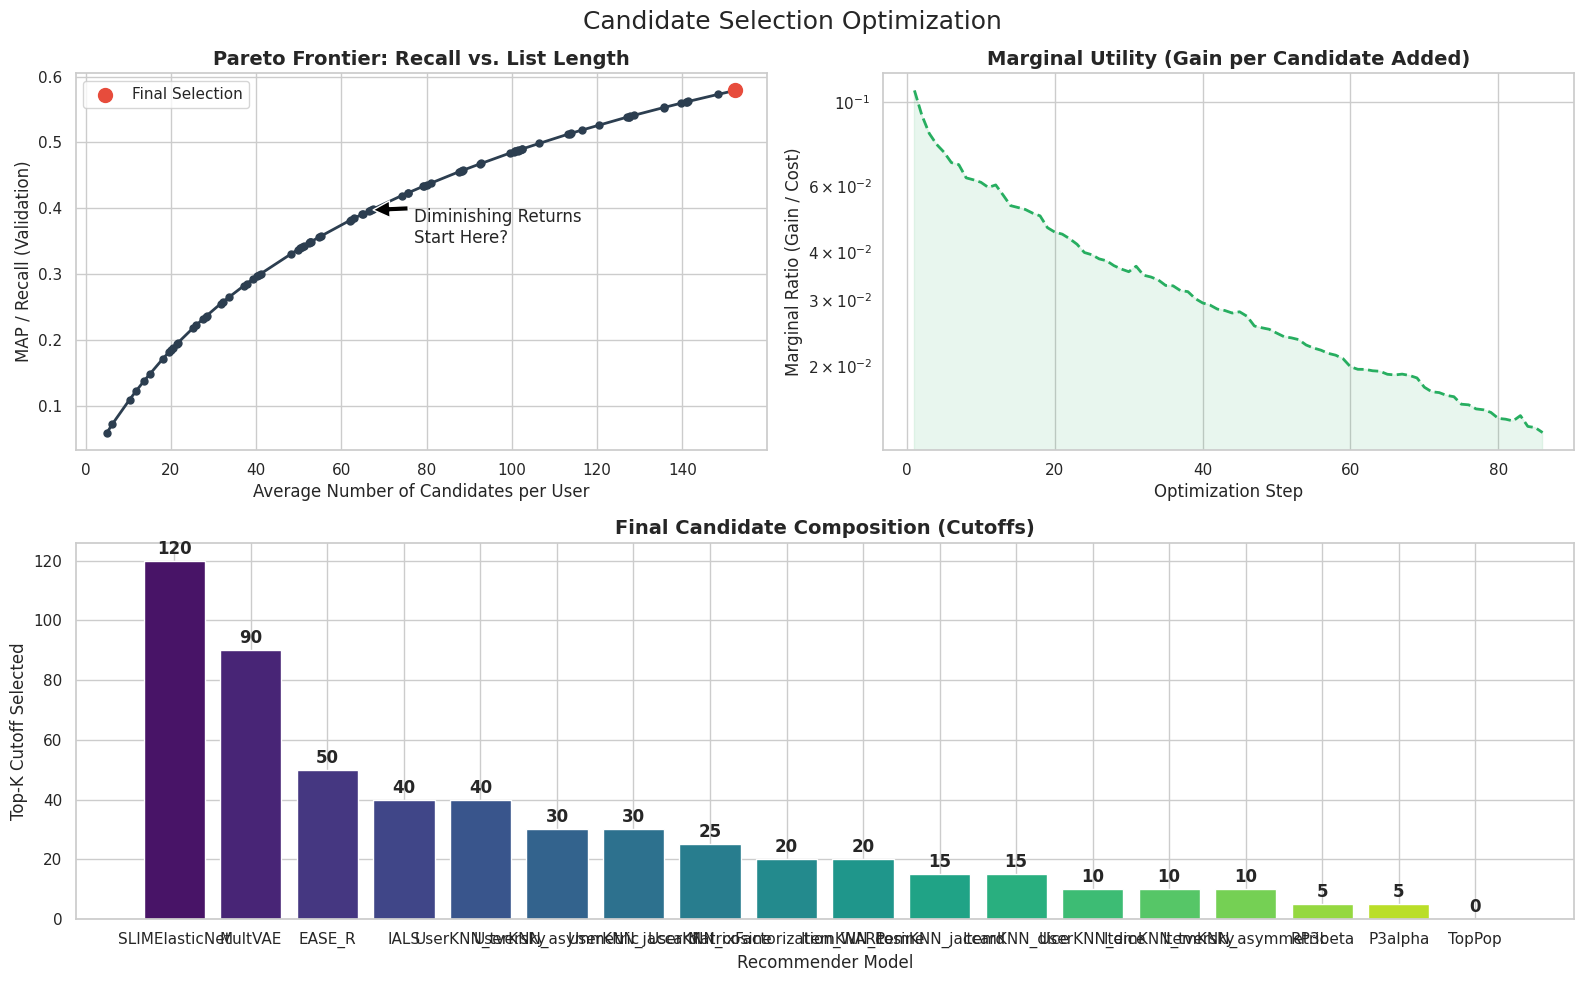

In [22]:
plot_candidate_selection_results(history, selected_cutoffs)

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


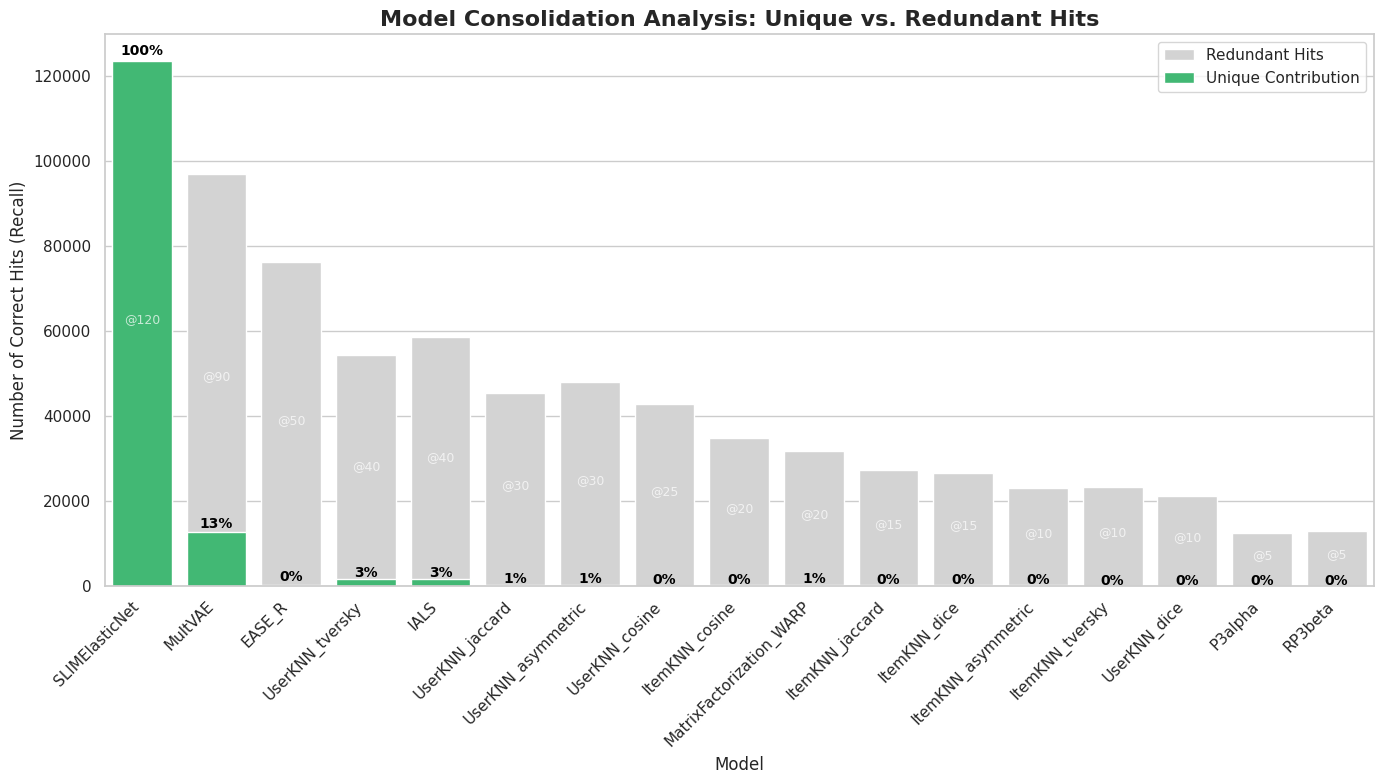

In [23]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, selected_cutoffs, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


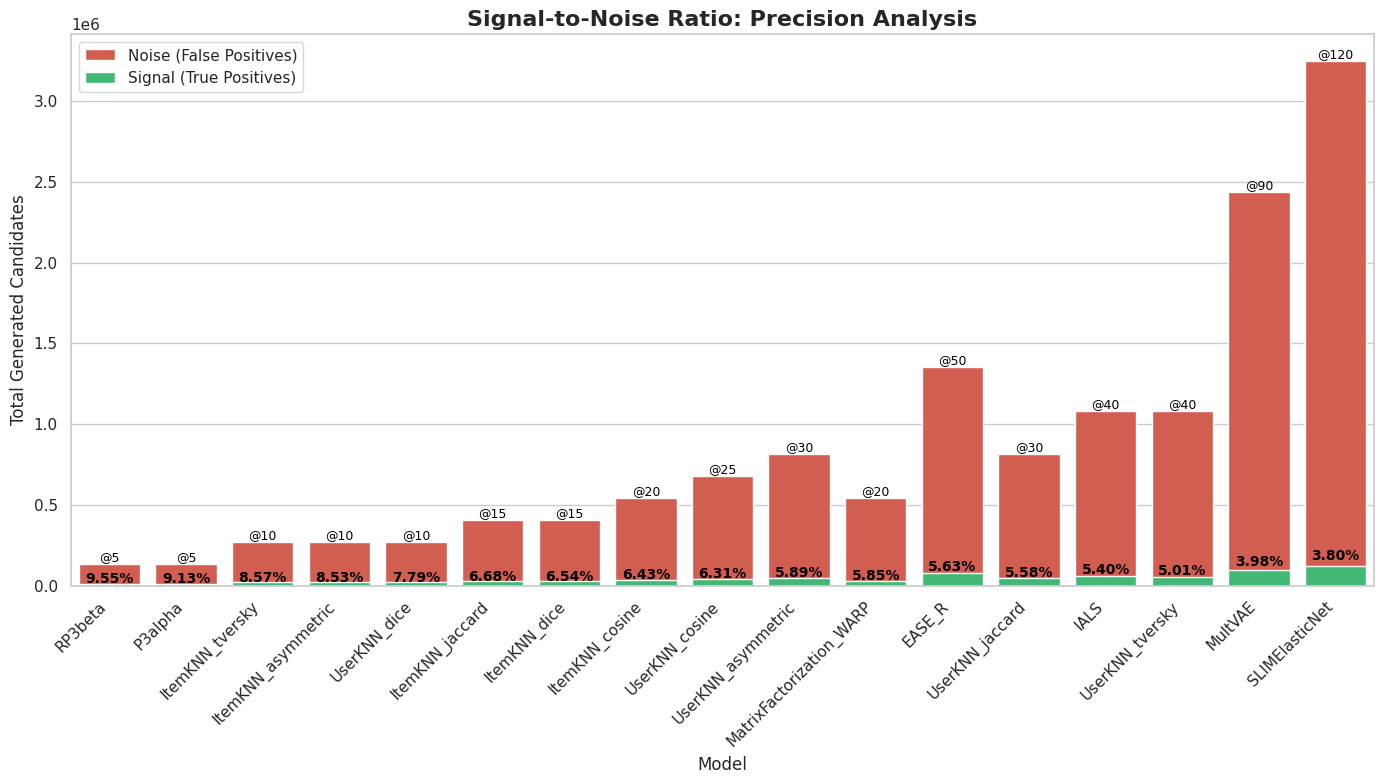

In [24]:
df_noise = analyze_candidate_noise(recs_cache_folds, selected_cutoffs, folds_10)
plot_noise_analysis(df_noise)

In [26]:
cutoffs_100 = reconstruct_cutoffs(history, target_candidates=100)
cutoffs_100

Target of 100 candidates reached at Step 59 (Actual: 100.59).


{'ItemKNN_cosine': 15,
 'UserKNN_tversky': 20,
 'MatrixFactorization_WARP': 0,
 'ItemKNN_tversky': 10,
 'ItemKNN_jaccard': 10,
 'ItemKNN_dice': 5,
 'RP3beta': 5,
 'P3alpha': 5,
 'MultVAE': 50,
 'UserKNN_cosine': 15,
 'UserKNN_dice': 5,
 'UserKNN_asymmetric': 20,
 'SLIMElasticNet': 80,
 'UserKNN_jaccard': 20,
 'EASE_R': 40,
 'ItemKNN_asymmetric': 10,
 'IALS': 30}

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


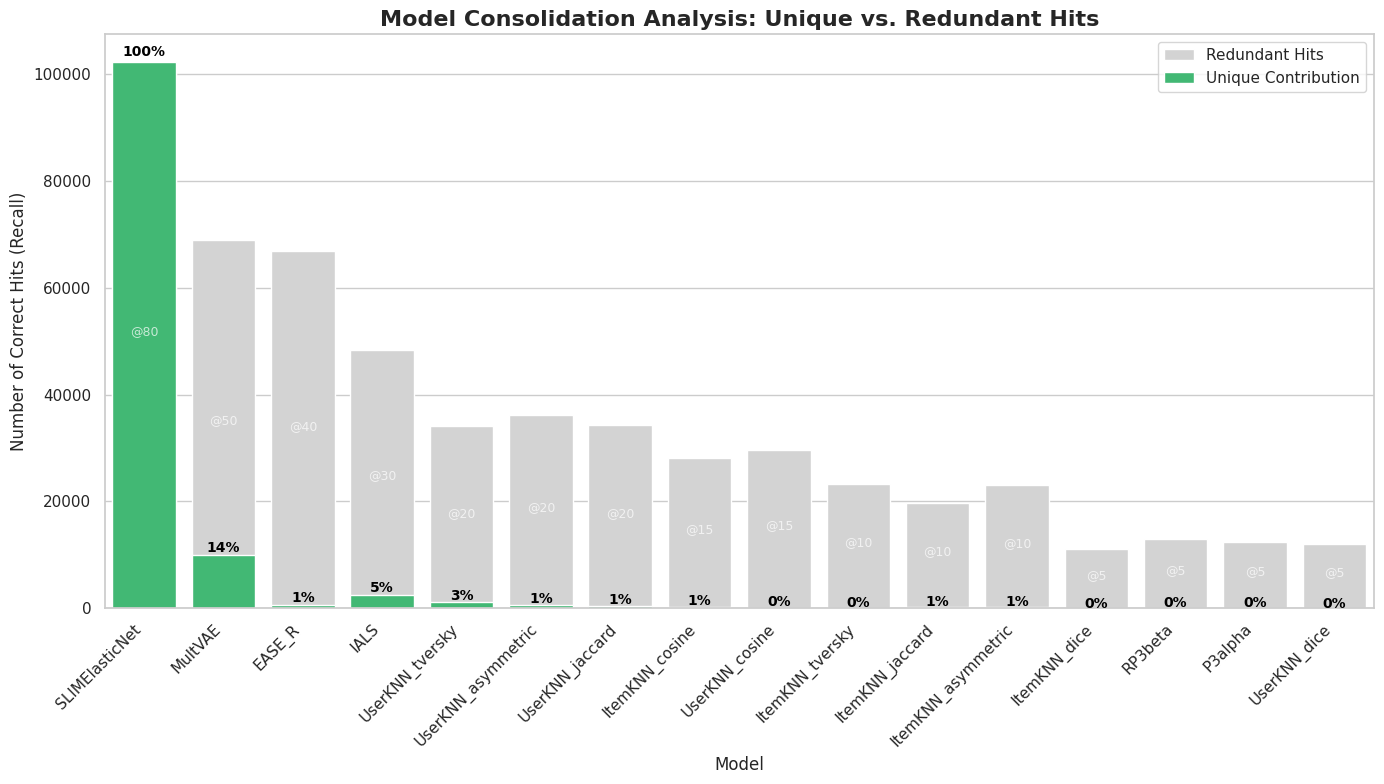

In [28]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, cutoffs_100, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


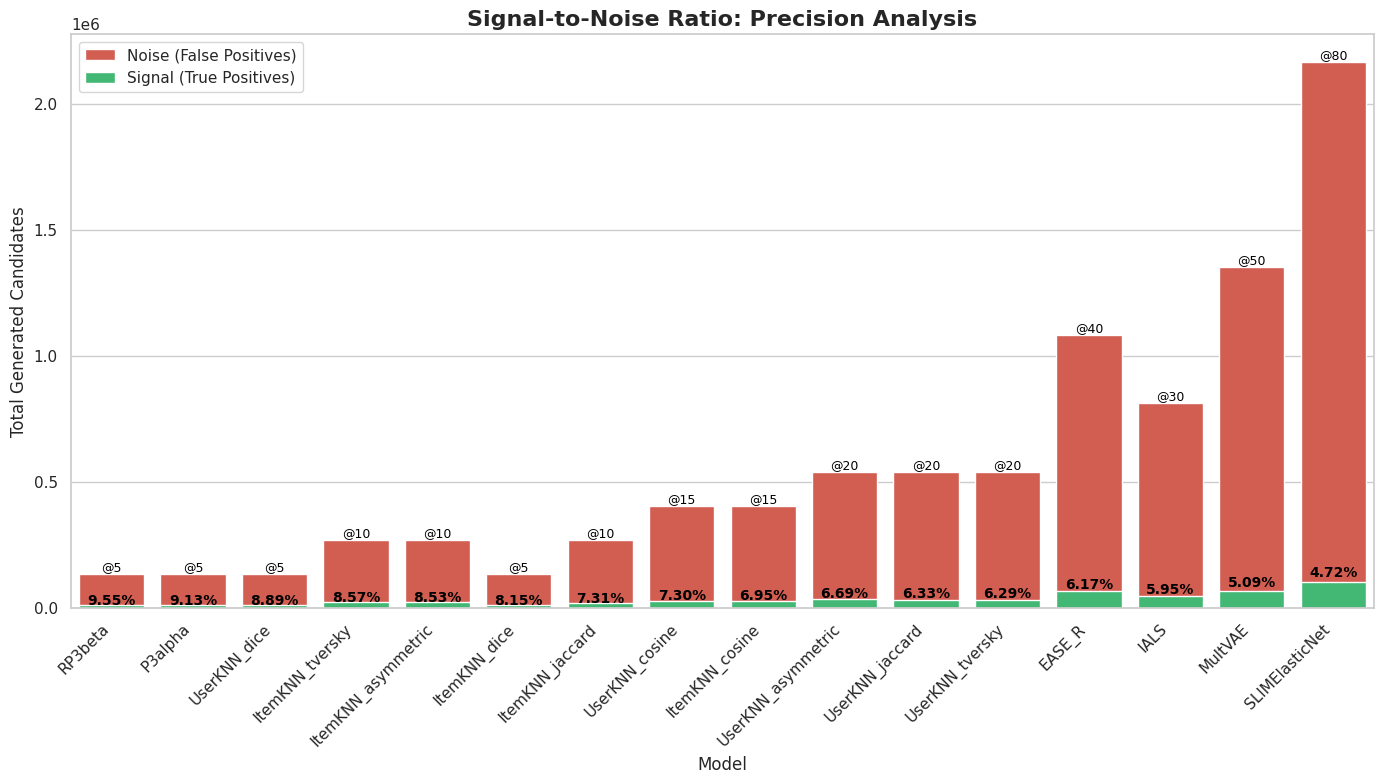

In [29]:
df_noise = analyze_candidate_noise(recs_cache_folds, cutoffs_100, folds_10)
plot_noise_analysis(df_noise)

In [30]:
cutoffs_80 = reconstruct_cutoffs(history, target_candidates=80)
cutoffs_80

Target of 80 candidates reached at Step 51 (Actual: 80.99).


{'ItemKNN_cosine': 10,
 'UserKNN_tversky': 20,
 'MatrixFactorization_WARP': 0,
 'ItemKNN_tversky': 10,
 'ItemKNN_jaccard': 5,
 'ItemKNN_dice': 5,
 'RP3beta': 5,
 'P3alpha': 5,
 'MultVAE': 40,
 'UserKNN_cosine': 15,
 'UserKNN_dice': 5,
 'UserKNN_asymmetric': 15,
 'SLIMElasticNet': 60,
 'UserKNN_jaccard': 15,
 'EASE_R': 40,
 'ItemKNN_asymmetric': 10,
 'IALS': 25}

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


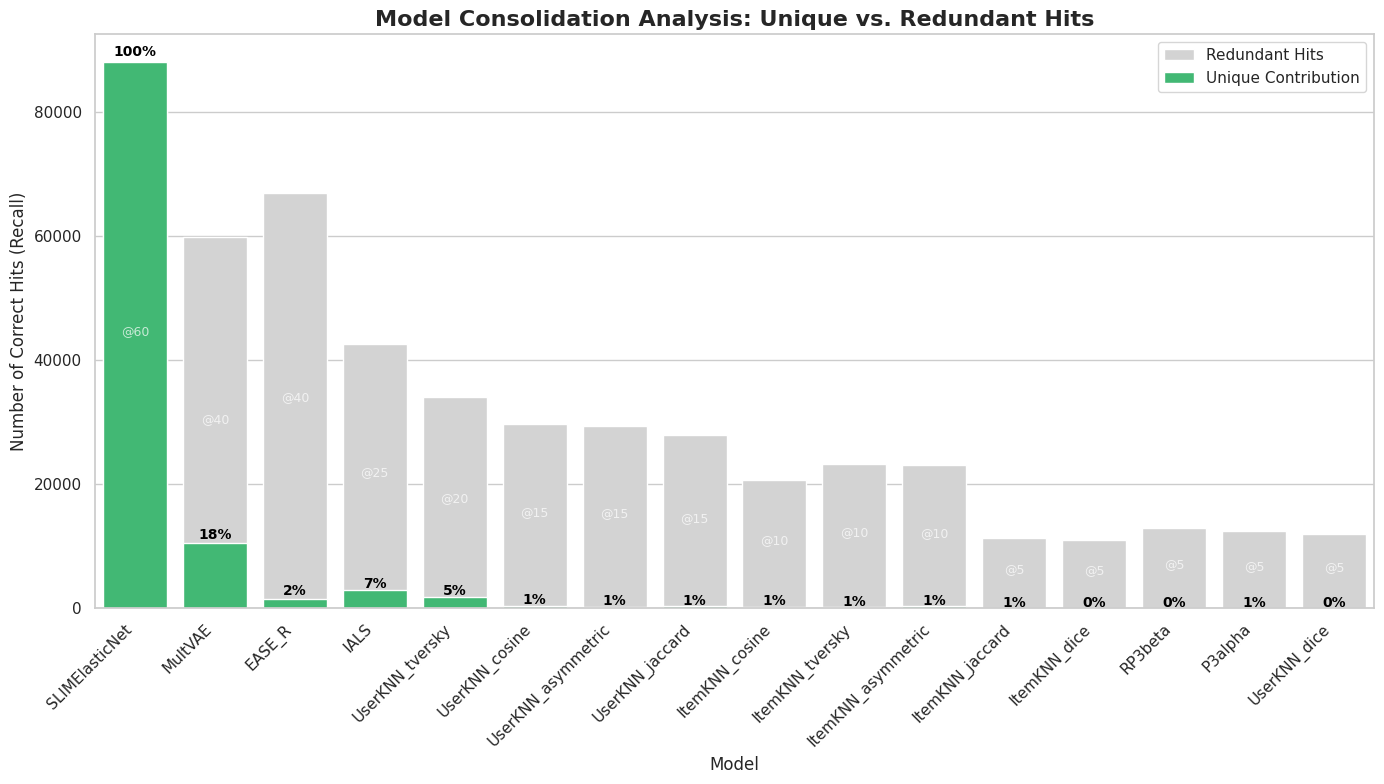

In [33]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, cutoffs_80, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


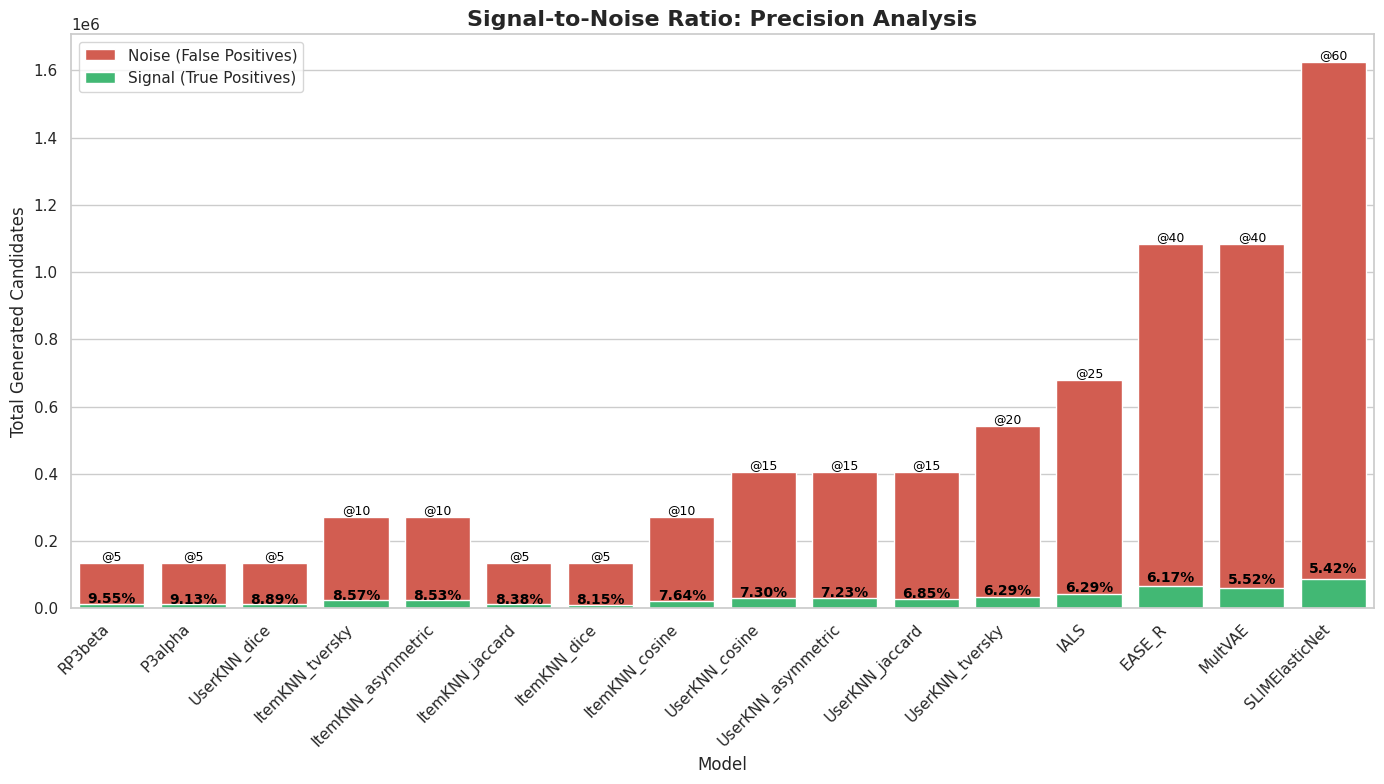

In [34]:
df_noise = analyze_candidate_noise(recs_cache_folds, cutoffs_80, folds_10)
plot_noise_analysis(df_noise)

In [35]:
cutoffs_60 = reconstruct_cutoffs(history, target_candidates=60)
cutoffs_60

Target of 60 candidates reached at Step 37 (Actual: 61.89).


{'ItemKNN_cosine': 5,
 'UserKNN_tversky': 10,
 'MatrixFactorization_WARP': 0,
 'ItemKNN_tversky': 10,
 'ItemKNN_jaccard': 5,
 'ItemKNN_dice': 0,
 'RP3beta': 5,
 'P3alpha': 5,
 'MultVAE': 25,
 'UserKNN_cosine': 10,
 'UserKNN_dice': 5,
 'UserKNN_asymmetric': 10,
 'SLIMElasticNet': 50,
 'UserKNN_jaccard': 10,
 'EASE_R': 25,
 'ItemKNN_asymmetric': 10,
 'IALS': 15}

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


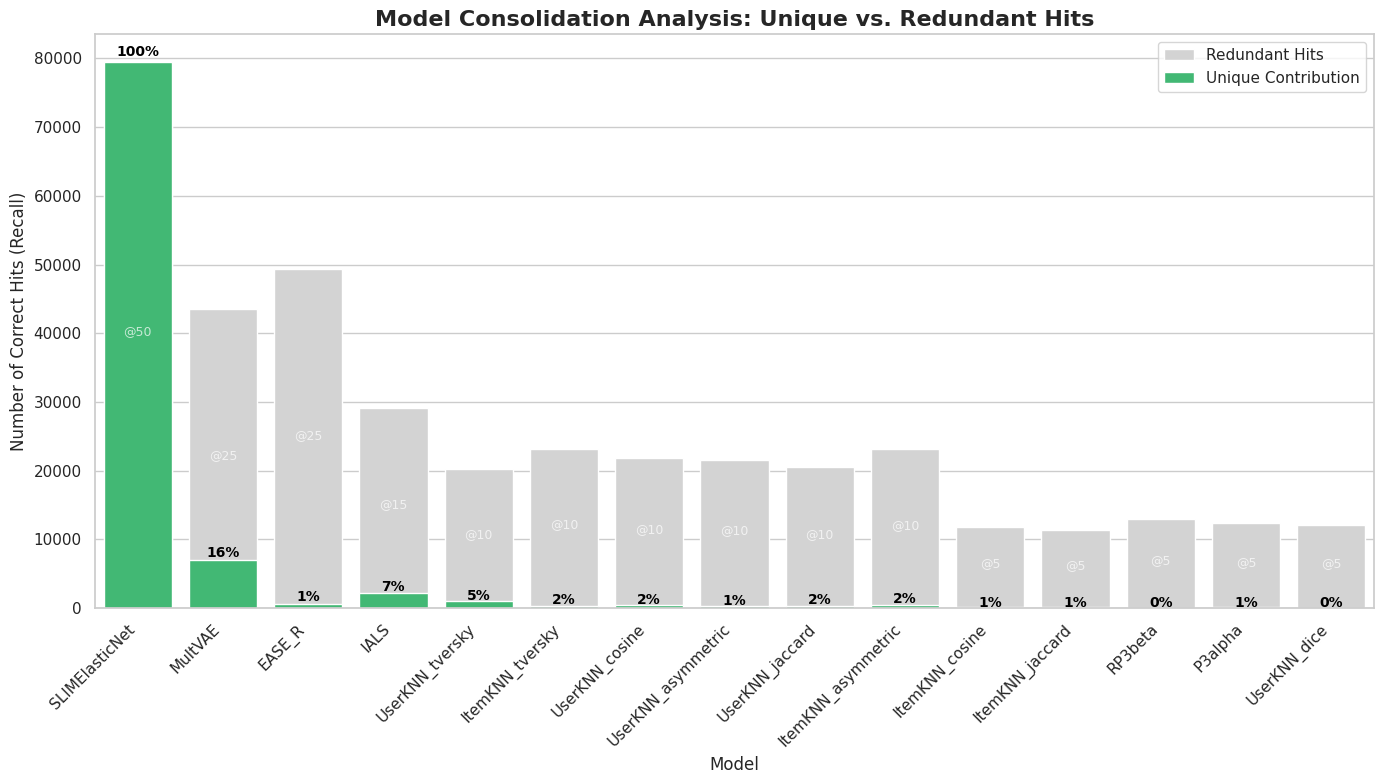

In [36]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, cutoffs_60, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


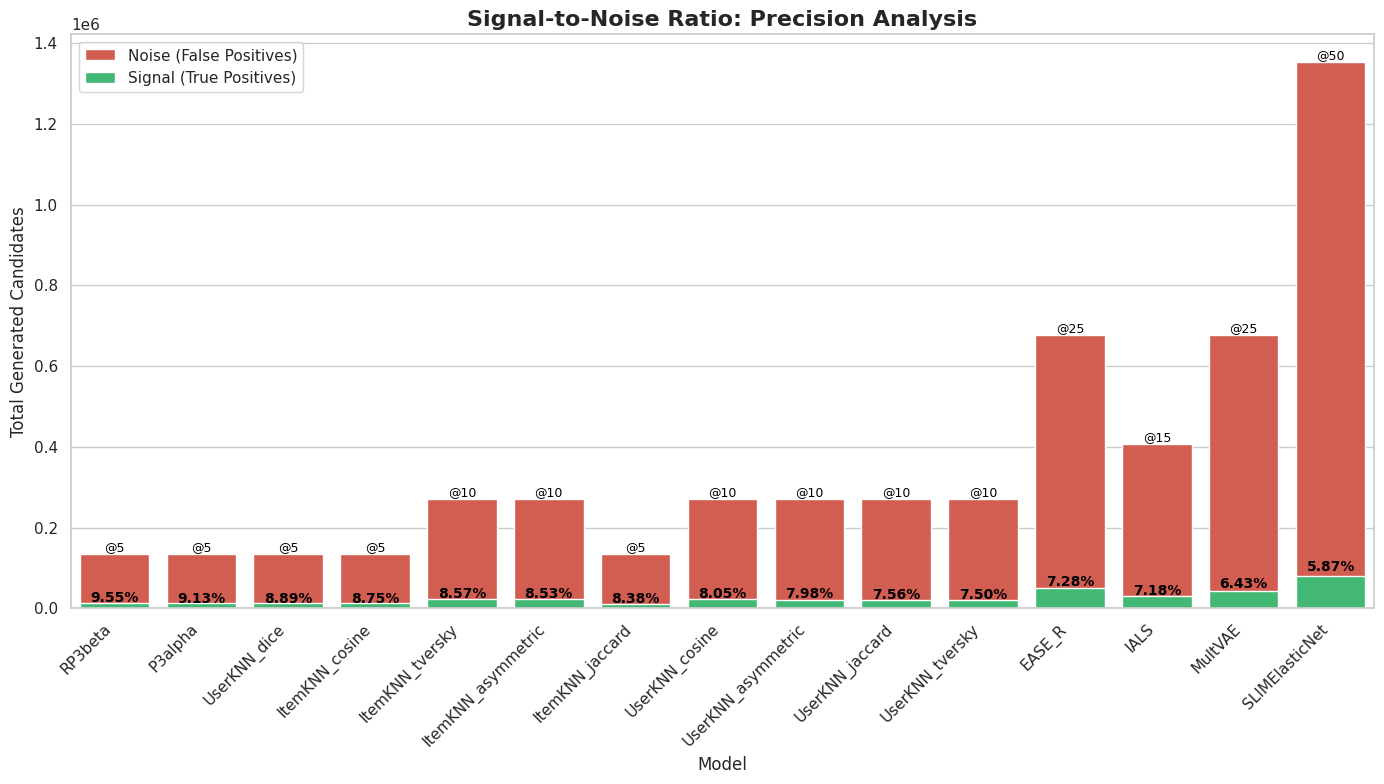

In [37]:
df_noise = analyze_candidate_noise(recs_cache_folds, cutoffs_60, folds_10)
plot_noise_analysis(df_noise)

In [ ]:
custom_cutoff = {
    'SLIMElasticNet': 60,
    'MultVAE': 40,
    'EASE_R': 40,
    'IALS': 25,
    'UserKNN_tversky': 20,
    'ItemKNN_cosine': 5,
    'ItemKNN_tversky': 5,
    'ItemKNN_jaccard': 5,
    'ItemKNN_dice': 5,
    'RP3beta': 5,
    'P3alpha': 5,
    'UserKNN_cosine': 5,
    'UserKNN_dice': 5,
    'UserKNN_asymmetric':5,
    'UserKNN_jaccard': 5,
    'ItemKNN_asymmetric': 5,
    'MatrixFactorization_WARP': 5
}

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


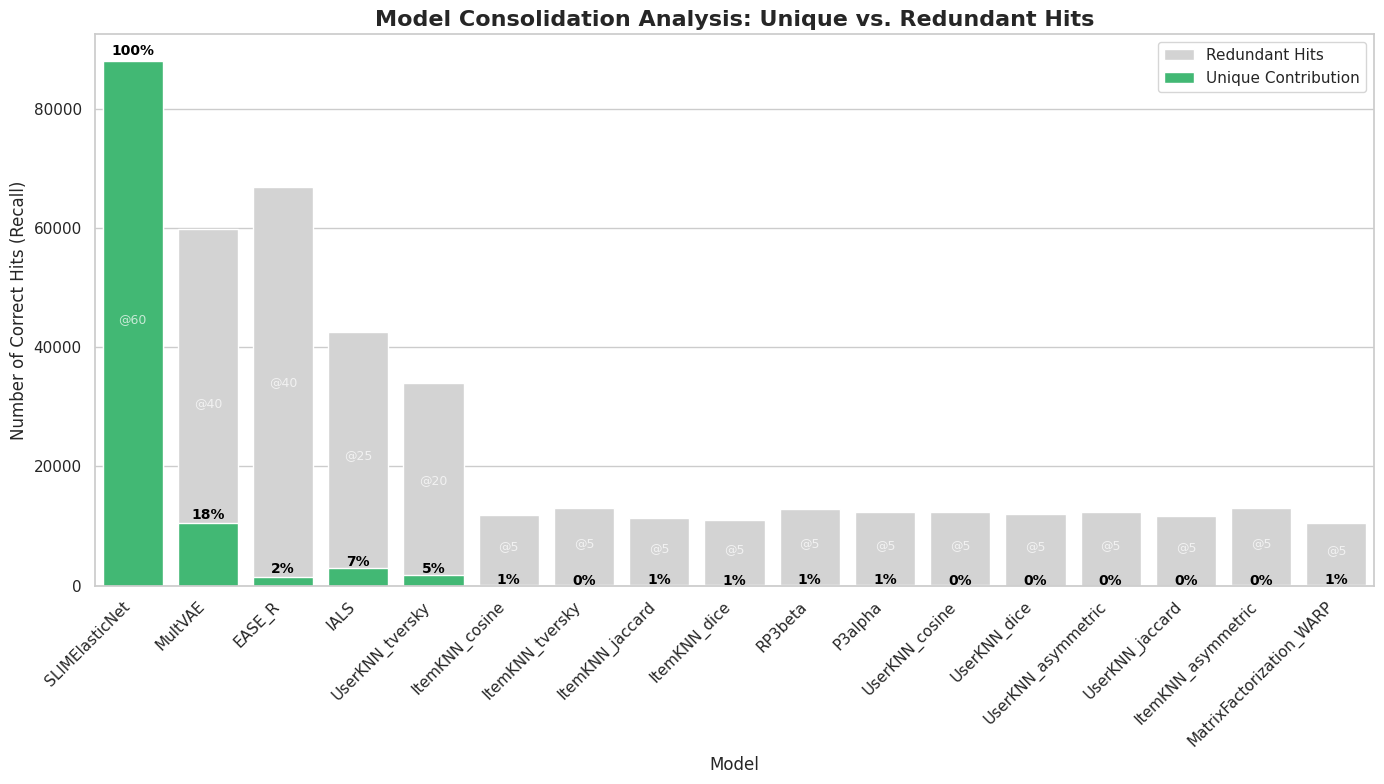

In [43]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, custom_cutoff, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


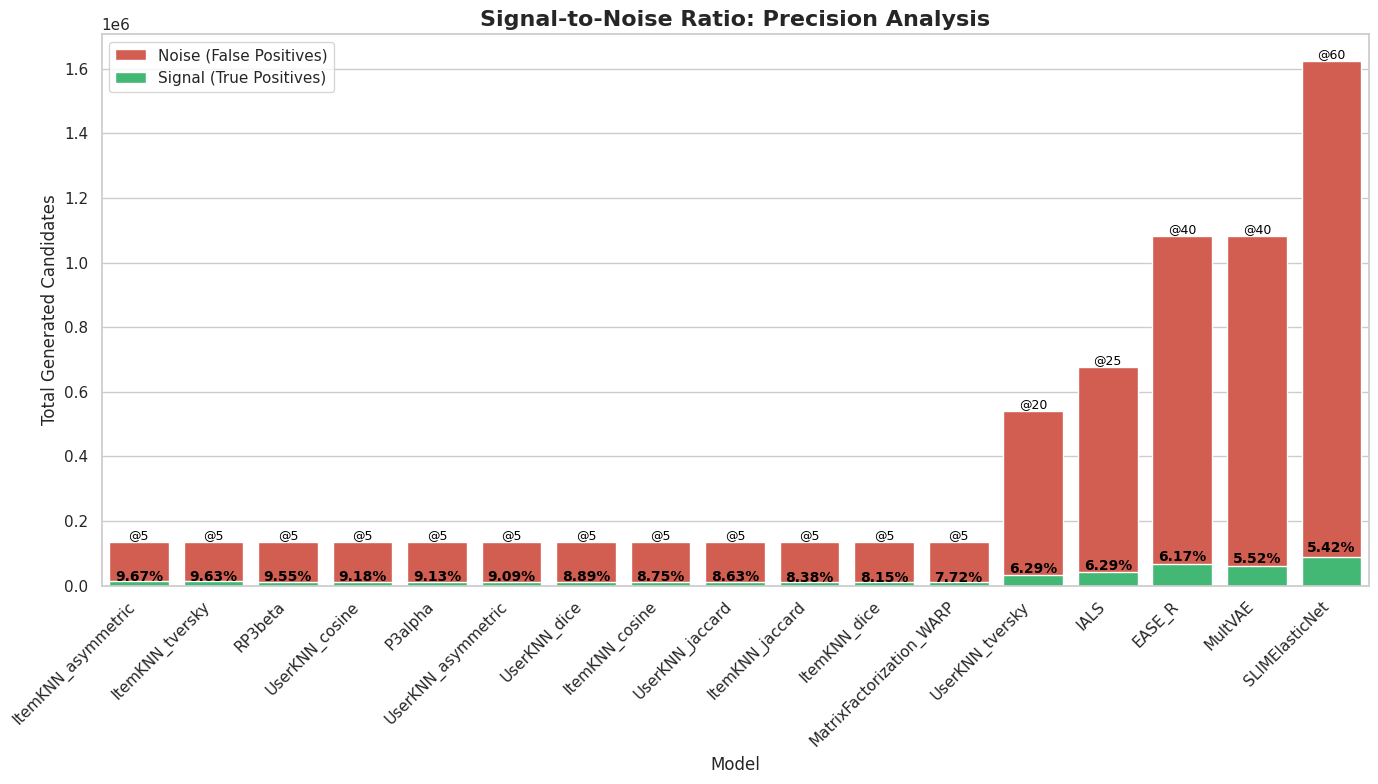

In [44]:
df_noise = analyze_candidate_noise(recs_cache_folds, custom_cutoff, folds_10)
plot_noise_analysis(df_noise)

## **Best models**

In [45]:
# 1. Define your Survivors
survivors = ['SLIMElasticNet', 'MultVAE', 'IALS', 'UserKNN_tversky', 'EASE_R']

# 2. Re-run the Greedy Selection ONLY on these keys
# Note: We pass the SAME recs_cache_folds, the function will just look up the specific keys
clean_cutoffs, clean_history = greedy_candidate_selection(
    recs_cache_folds,
    survivors,
    folds_10,
    cutoffs, 
    budget=100
)

print("New Optimized Cutoffs:", clean_cutoffs)

Selected SLIMElasticNet @ 5. Ratio: 0.10722. Avg Cand: 5.00. Avg Recall: 0.05967
Selected EASE_R @ 5. Ratio: 0.09226. Avg Cand: 6.24. Avg Recall: 0.07235
Selected SLIMElasticNet @ 10. Ratio: 0.08257. Avg Cand: 10.28. Avg Recall: 0.10951
Selected MultVAE @ 5. Ratio: 0.07430. Avg Cand: 12.25. Avg Recall: 0.12578
Selected EASE_R @ 10. Ratio: 0.07120. Avg Cand: 13.83. Avg Recall: 0.13835
Selected SLIMElasticNet @ 15. Ratio: 0.06966. Avg Cand: 17.22. Avg Recall: 0.16463
Selected IALS @ 5. Ratio: 0.06351. Avg Cand: 18.60. Avg Recall: 0.17437
Selected SLIMElasticNet @ 20. Ratio: 0.05923. Avg Cand: 22.68. Avg Recall: 0.20128
Selected EASE_R @ 15. Ratio: 0.05670. Avg Cand: 23.65. Avg Recall: 0.20736
Selected UserKNN_tversky @ 5. Ratio: 0.05567. Avg Cand: 24.62. Avg Recall: 0.21342
Selected MultVAE @ 10. Ratio: 0.05383. Avg Cand: 26.31. Avg Recall: 0.22353
Selected SLIMElasticNet @ 25. Ratio: 0.05162. Avg Cand: 29.94. Avg Recall: 0.24438
Selected EASE_R @ 20. Ratio: 0.04673. Avg Cand: 31.10. Avg

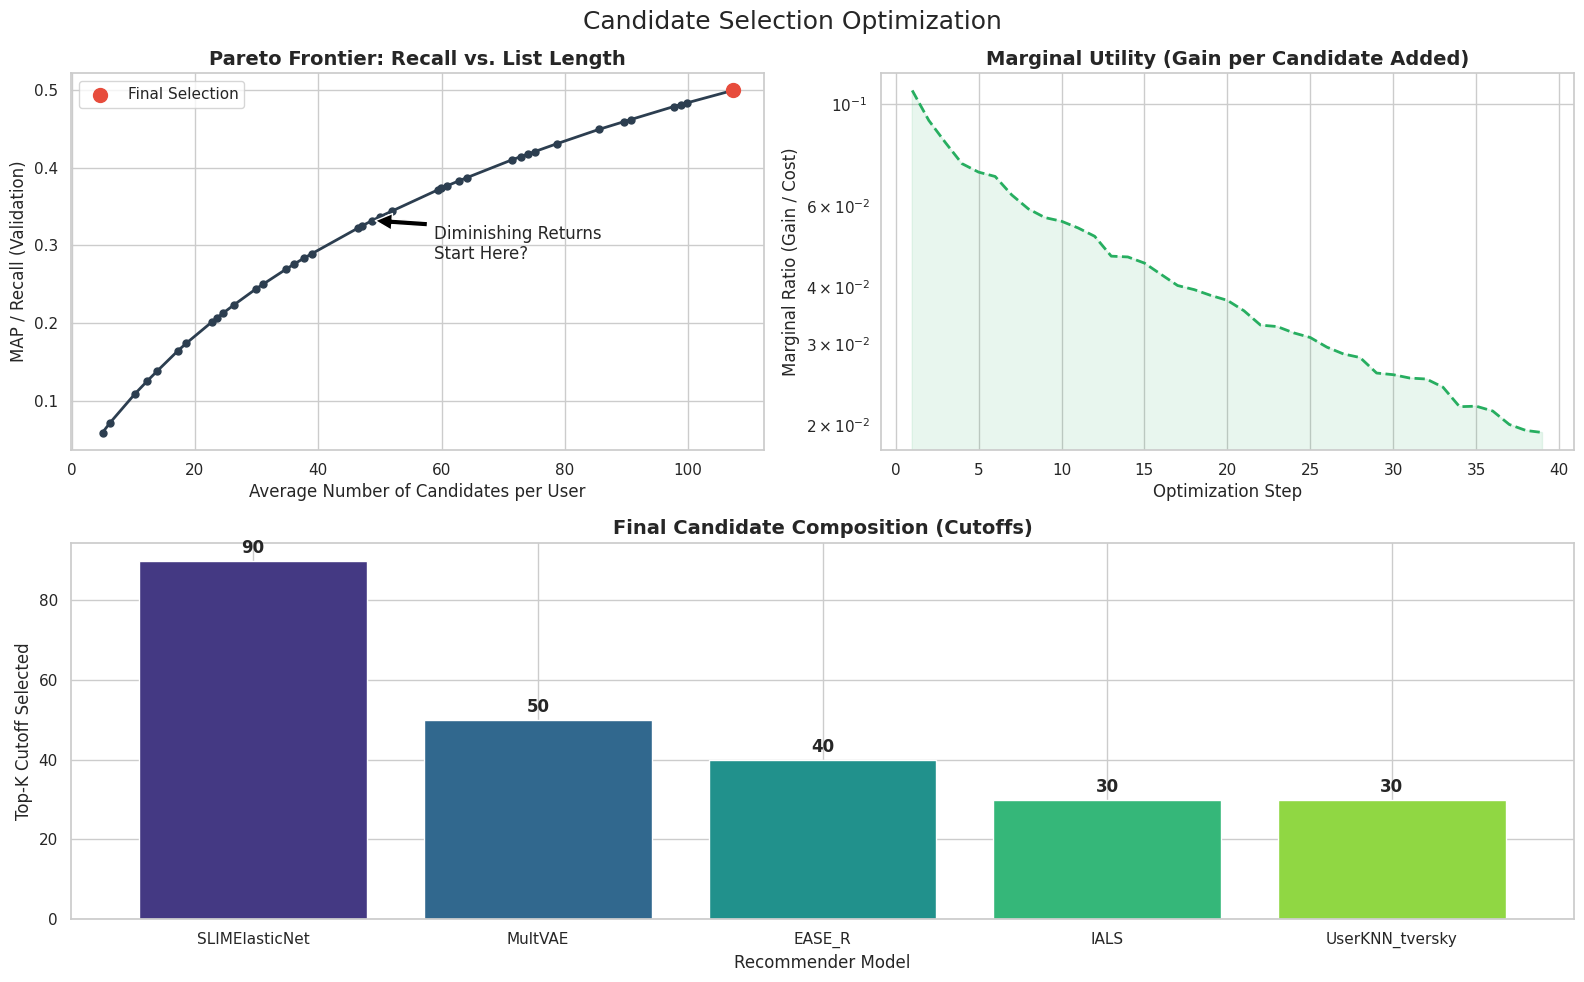

In [46]:
plot_candidate_selection_results(clean_history, clean_cutoffs)

/tmp/ipykernel_10207/948188564.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


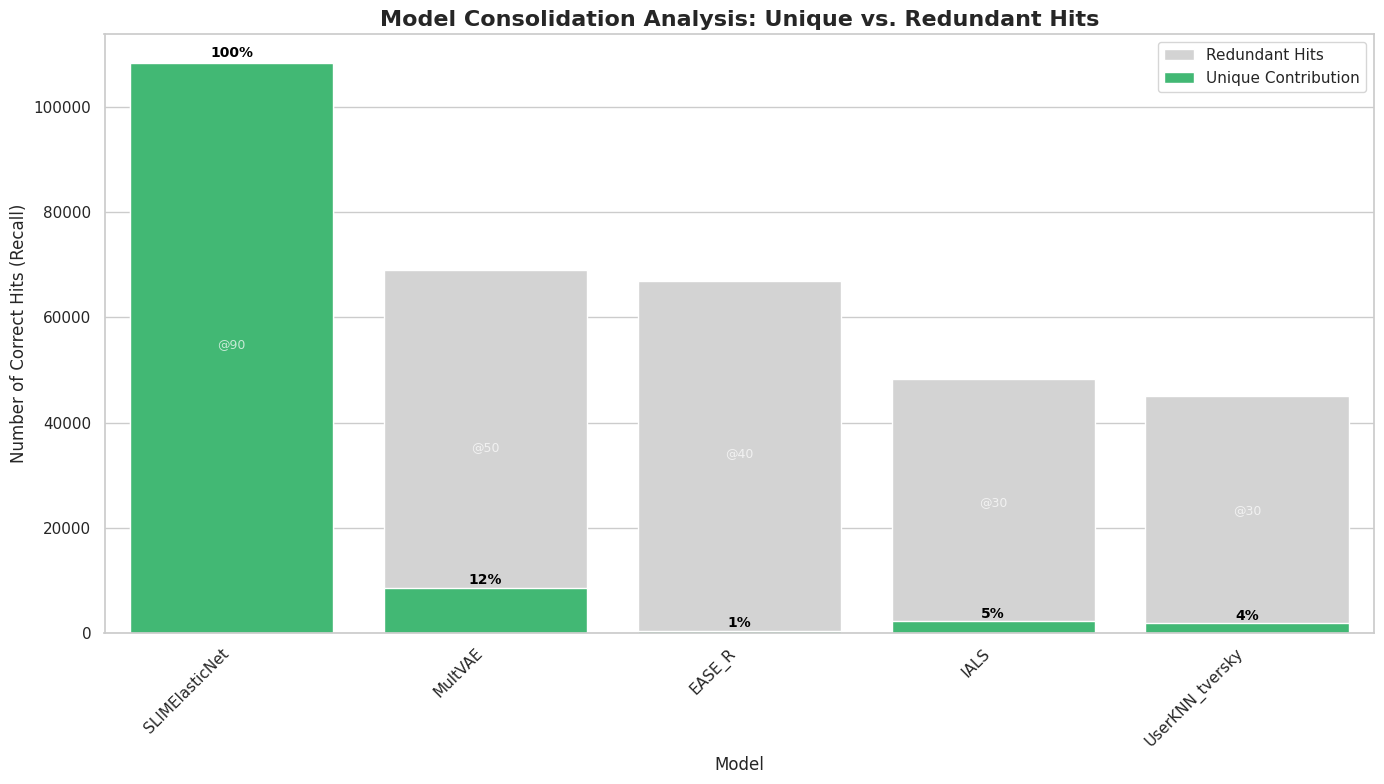

In [47]:
df_redundancy = analyze_candidate_redundancy(recs_cache_folds, clean_cutoffs, folds_10)
plot_redundancy(df_redundancy)

/tmp/ipykernel_10207/2433678149.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


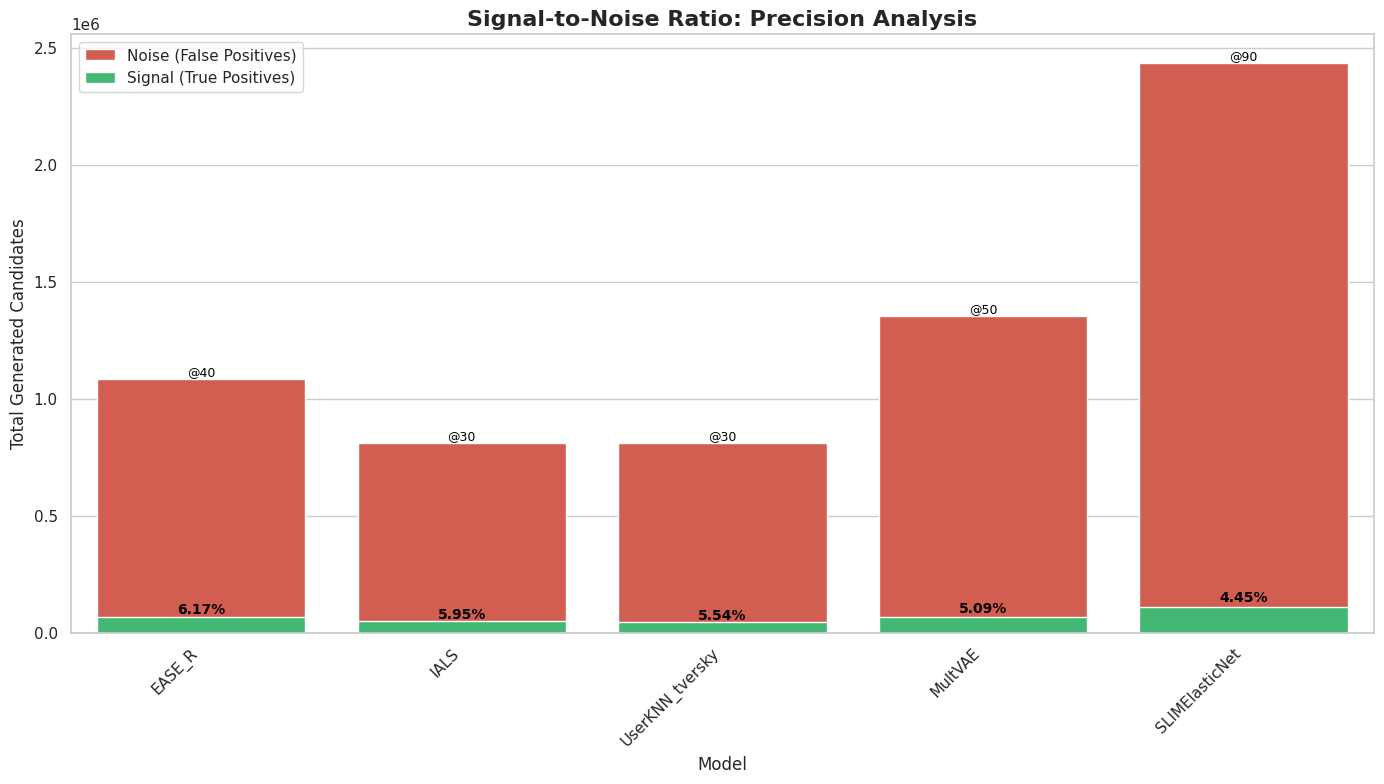

In [48]:
df_noise = analyze_candidate_noise(recs_cache_folds, clean_cutoffs, folds_10)
plot_noise_analysis(df_noise)

In [49]:
# Define the milestones you care about
milestones = [10, 20, 30, 40, 50, 80]
checkpoint_cutoffs = {}

for m in milestones:
    # Use the function we defined earlier to "rewind" history
    # Note: Pass the 'history' object returned by greedy_candidate_selection
    cutoffs_at_m = reconstruct_cutoffs(clean_history, target_candidates=m)
    checkpoint_cutoffs[m] = cutoffs_at_m
    print(f"Budget {m}: {cutoffs_at_m}")

Target of 10 candidates reached at Step 2 (Actual: 10.28).
Budget 10: {'UserKNN_tversky': 0, 'MultVAE': 0, 'SLIMElasticNet': 10, 'EASE_R': 5, 'IALS': 0}
Target of 20 candidates reached at Step 7 (Actual: 22.68).
Budget 20: {'UserKNN_tversky': 0, 'MultVAE': 5, 'SLIMElasticNet': 20, 'EASE_R': 10, 'IALS': 5}
Target of 30 candidates reached at Step 12 (Actual: 31.10).
Budget 30: {'UserKNN_tversky': 5, 'MultVAE': 10, 'SLIMElasticNet': 25, 'EASE_R': 20, 'IALS': 5}
Target of 40 candidates reached at Step 17 (Actual: 46.50).
Budget 40: {'UserKNN_tversky': 10, 'MultVAE': 15, 'SLIMElasticNet': 40, 'EASE_R': 20, 'IALS': 10}
Target of 50 candidates reached at Step 20 (Actual: 50.04).
Budget 50: {'UserKNN_tversky': 10, 'MultVAE': 20, 'SLIMElasticNet': 40, 'EASE_R': 25, 'IALS': 15}
Target of 80 candidates reached at Step 32 (Actual: 85.56).
Budget 80: {'UserKNN_tversky': 20, 'MultVAE': 40, 'SLIMElasticNet': 70, 'EASE_R': 40, 'IALS': 25}


## **Validation**

In [50]:
URM_train = URM_inner
URM_val = URM_outer
user_ids = np.arange(URM_train.shape[0])
recs_cache_val = {}
model_names = list(models_mapping.keys()) + ['EASE_R']

In [51]:
name, model = train_all_models(URM_train, {'EASE_R': EASE_R_Recommender})[0]
trained_models = train_all_models(URM_train, models_mapping)

print(f"Precomputing recommendations for {name}...")
recommended_items = model.recommend(user_ids, cutoff=max_cutoff)
recs_cache_val[name] = np.array(recommended_items)

for model_name, model in trained_models:
    print(f"Precomputing recommendations for {model_name}...")
    model_names.append(model_name)

    if type(model) == AlternatingLeastSquares:
        recommended_items, scores = model.recommend(
            user_ids, 
            URM_train, 
            N=max_cutoff, 
            filter_already_liked_items=True
        )

    elif type(model) == MultVAERecommender_PyTorch_OptimizerMask:
        # Do in batches to avoid OOM in GPU
        recommended_items = []
        for user_batch in get_user_batches(user_ids, batch_size=500):
            batch_recs = model.recommend(user_batch, cutoff=max_cutoff)
            recommended_items.extend(batch_recs)
        recommended_items = recommended_items

    else:
        recommended_items = model.recommend(user_ids, cutoff=max_cutoff)

    recs_cache_val[model_name] = np.array(recommended_items)

# Free memory
del trained_models, model
gc.collect()

  Training model: EASE_R
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 7.48 sec
  Training model: TopPop
  Training model: ItemKNN_cosine
Similarity column 6969 (100.0%), 4601.04 column/sec. Elapsed time 1.51 sec
  Training model: ItemKNN_jaccard
Similarity column 6969 (100.0%), 4562.66 column/sec. Elapsed time 1.53 sec
  Training model: ItemKNN_asymmetric
Similarity column 6969 (100.0%), 4049.78 column/sec. Elapsed time 1.72 sec
  Training model: ItemKNN_tversky
Similarity column 6969 (100.0%), 4598.26 column/sec. Elapsed time 1.52 sec
  Training model: ItemKNN_dice
Similarity column 6969 (100.0%), 4491.19 column/sec. Elapsed time 1.55 sec
  Training model: UserKNN_cosine
Similarity column 27095 (100.0%), 1832.76 column/sec. Elapsed time 14.78 sec
  Training model: UserKNN_jaccard
Similarity column 27095 (100.0%), 1801.91 column/sec. Elapsed time 15.04 sec
  Training model: UserKNN_asymmetric
Similarity column 27095 (100.0%), 1839.88 column/sec. El

  0%|          | 0/31 [00:00<?, ?it/s]

  Training model: MatrixFactorization_WARP
MF_WARP: Processed 27648 (100.0%) in 0.82 sec. MSE loss 8.32E-02. Sample per second: 33638
MF_WARP: Epoch 1 of 1500. Elapsed time 0.19 sec
MF_WARP: Processed 27648 (100.0%) in 1.00 sec. MSE loss 1.47E-01. Sample per second: 27543
MF_WARP: Epoch 2 of 1500. Elapsed time 0.38 sec
MF_WARP: Processed 27648 (100.0%) in 0.17 sec. MSE loss 1.97E-01. Sample per second: 162682
MF_WARP: Epoch 3 of 1500. Elapsed time 0.54 sec
MF_WARP: Processed 27648 (100.0%) in 0.33 sec. MSE loss 2.35E-01. Sample per second: 84948
MF_WARP: Epoch 4 of 1500. Elapsed time 0.70 sec
MF_WARP: Processed 27648 (100.0%) in 0.48 sec. MSE loss 2.83E-01. Sample per second: 57363
MF_WARP: Epoch 5 of 1500. Elapsed time 0.85 sec
MF_WARP: Processed 27648 (100.0%) in 0.63 sec. MSE loss 3.46E-01. Sample per second: 43605
MF_WARP: Epoch 6 of 1500. Elapsed time 1.01 sec
MF_WARP: Processed 27648 (100.0%) in 0.78 sec. MSE loss 4.68E-01. Sample per second: 35353
MF_WARP: Epoch 7 of 1500. Elaps

100%|█████████▉| 6968/6969 [01:31<00:00, 75.91it/s] 


Precomputing recommendations for EASE_R...
Precomputing recommendations for TopPop...
Precomputing recommendations for ItemKNN_cosine...
Precomputing recommendations for ItemKNN_jaccard...
Precomputing recommendations for ItemKNN_asymmetric...
Precomputing recommendations for ItemKNN_tversky...
Precomputing recommendations for ItemKNN_dice...
Precomputing recommendations for UserKNN_cosine...
Precomputing recommendations for UserKNN_jaccard...
Precomputing recommendations for UserKNN_asymmetric...
Precomputing recommendations for UserKNN_tversky...
Precomputing recommendations for UserKNN_dice...
Precomputing recommendations for P3alpha...
Precomputing recommendations for RP3beta...
Precomputing recommendations for IALS...
Precomputing recommendations for MatrixFactorization_WARP...
Precomputing recommendations for MultVAE...
Precomputing recommendations for SLIMElasticNet...


0

In [52]:
def gen_recommendations(recs_cache, cutoffs, user_ids):
    final_recommendations = {}

    for user_id in user_ids:
        recommended_items_set = set()

        for model_name, cutoff in cutoffs.items():
            if cutoff > 0:
                model_recs = recs_cache[model_name][user_id][:cutoff]
                recommended_items_set.update(model_recs)

        final_recommendations[user_id] = list(recommended_items_set)

    return final_recommendations

In [53]:
baseline_cutoff = {
    'SLIMElasticNet': 80,
    'MultVAE': 60,
    'IALS': 60,
    'RP3beta': 20,
    'UserKNN_tversky': 30,
    'ItemKNN_tversky': 30,
    'MatrixFactorization_WARP': 30,
    'TopPop': 50,
}

custom_cutoff = {
    'SLIMElasticNet': 60,
    'MultVAE': 40,
    'EASE_R': 40,
    'IALS': 25,
    'UserKNN_tversky': 20,
    'ItemKNN_cosine': 5,
    'ItemKNN_tversky': 5,
    'ItemKNN_jaccard': 5,
    'ItemKNN_dice': 5,
    'RP3beta': 5,
    'P3alpha': 5,
    'UserKNN_cosine': 5,
    'UserKNN_dice': 5,
    'UserKNN_asymmetric':5,
    'UserKNN_jaccard': 5,
    'ItemKNN_asymmetric': 5,
    'MatrixFactorization_WARP': 5
}

rec_baseline = gen_recommendations(recs_cache_val, baseline_cutoff, user_ids)
rec_40 = gen_recommendations(recs_cache_val, checkpoint_cutoffs[40], user_ids)
rec_50 = gen_recommendations(recs_cache_val, checkpoint_cutoffs[50], user_ids)
rec_80 = gen_recommendations(recs_cache_val, checkpoint_cutoffs[80], user_ids)
rec_custom = gen_recommendations(recs_cache_val, custom_cutoff, user_ids)
rec_clean = gen_recommendations(recs_cache_val, clean_cutoffs, user_ids)
rec_all_150 = gen_recommendations(recs_cache_val, selected_cutoffs, user_ids)
rec_all_100 = gen_recommendations(recs_cache_val, cutoffs_100, user_ids)
rec_all_80 = gen_recommendations(recs_cache_val, cutoffs_80, user_ids)
rec_all_60 = gen_recommendations(recs_cache_val, cutoffs_60, user_ids)

candidate_sets = {
    "Baseline": rec_baseline,
    "Cutoff 40": rec_40,
    "Cutoff 50": rec_50,
    "Cutoff 80": rec_80,
    "Custom": rec_custom,
    "Clean (Optimized)": rec_clean,
    "All @ 150": rec_all_150,
    "All @ 100": rec_all_100,
    "All @ 80": rec_all_80,
    "All @ 60": rec_all_60,
}

In [54]:
def evaluate_candidates(candidates_dict, URM_validation, user_ids):
    """
    Calculates performance metrics for a dictionary of candidate lists.
    """
    total_candidates = 0
    total_hits = 0
    
    # Pre-calculate total ground truth items for these users for Recall
    relevant_items_count = 0
    
    for user_id in user_ids:
        # Get Ground Truth
        start_pos = URM_validation.indptr[user_id]
        end_pos = URM_validation.indptr[user_id + 1]
        ground_truth = URM_validation.indices[start_pos:end_pos]
        
        relevant_items_count += len(ground_truth)
        
        # Get Recommendations
        recs = candidates_dict.get(user_id, [])
        total_candidates += len(recs)
        
        # Calculate Hits (Intersection)
        if len(recs) > 0 and len(ground_truth) > 0:
            hits = np.intersect1d(recs, ground_truth)
            total_hits += len(hits)

    precision = total_hits / total_candidates if total_candidates > 0 else 0.0
    recall = total_hits / relevant_items_count if relevant_items_count > 0 else 0.0
    
    return {
        "Total Candidates": total_candidates,
        "Total Hits": total_hits,
        "Precision": precision,
        "Recall": recall
    }

Evaluating candidate sets...
Processing Baseline...
Processing Cutoff 40...
Processing Cutoff 50...
Processing Cutoff 80...
Processing Custom...
Processing Clean (Optimized)...
Processing All @ 150...
Processing All @ 100...
Processing All @ 80...
Processing All @ 60...


/tmp/ipykernel_10207/2767259895.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y="Total Candidates", data=df_results, ax=axes[0,0], palette="Blues_d")
/tmp/ipykernel_10207/2767259895.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y="Total Hits", data=df_results, ax=axes[0,1], palette="Greens_d")
/tmp/ipykernel_10207/2767259895.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y="Recall", data=df_results, ax=axes[1,1], palette="Purples_d")


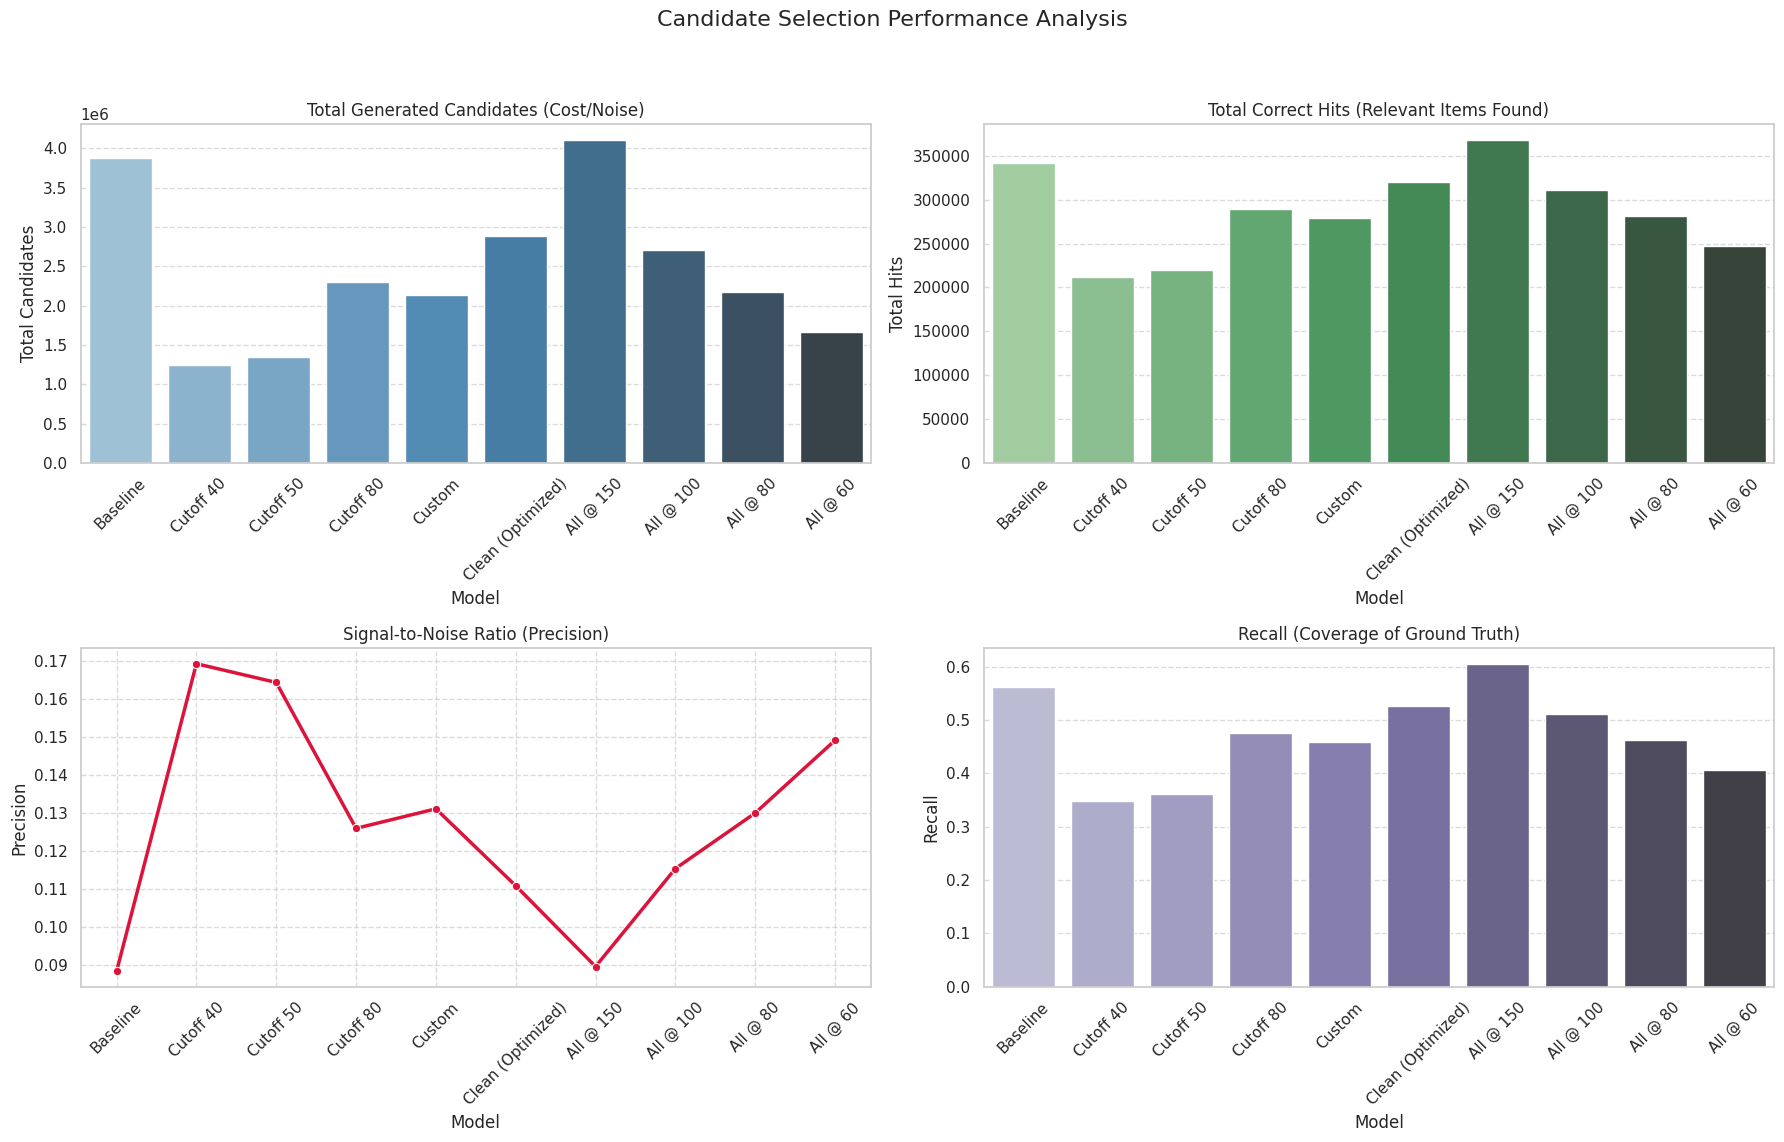

,Total Candidates,Total Hits,Precision,Recall
Model,,,,
All @ 150,4102250,367680,0.089629,0.604129
Baseline,3874548,342292,0.088344,0.562414
Clean (Optimized),2885229,319786,0.110836,0.525435
All @ 100,2702086,311713,0.115360,0.512170
Cutoff 80,2296574,289183,0.125919,0.475152
All @ 80,2169818,281986,0.129958,0.463326
Custom,2133165,279552,0.131050,0.459327
All @ 60,1661229,247626,0.149062,0.406870
Cutoff 50,1341604,220360,0.164251,0.362070


In [55]:
# 2. Run Evaluation
results = []
print("Evaluating candidate sets...")
for name, recs in candidate_sets.items():
    print(f"Processing {name}...")
    metrics = evaluate_candidates(recs, URM_val, user_ids) # Assuming URM_val is your validation matrix
    metrics["Model"] = name
    results.append(metrics)

df_results = pd.DataFrame(results)
df_results = df_results.set_index("Model")

# 3. Plotting
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle("Candidate Selection Performance Analysis", fontsize=16)

# Plot 1: Total Candidates (The Cost)
sns.barplot(x=df_results.index, y="Total Candidates", data=df_results, ax=axes[0,0], palette="Blues_d")
axes[0,0].set_title("Total Generated Candidates (Cost/Noise)")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Total Hits (The Value)
sns.barplot(x=df_results.index, y="Total Hits", data=df_results, ax=axes[0,1], palette="Greens_d")
axes[0,1].set_title("Total Correct Hits (Relevant Items Found)")
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Precision (Signal-to-Noise Ratio)
sns.lineplot(x=df_results.index, y="Precision", data=df_results, marker="o", ax=axes[1,0], color="crimson", linewidth=2.5)
axes[1,0].set_title("Signal-to-Noise Ratio (Precision)")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Recall (Useful Information)
sns.barplot(x=df_results.index, y="Recall", data=df_results, ax=axes[1,1], palette="Purples_d")
axes[1,1].set_title("Recall (Coverage of Ground Truth)")
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Display Data Table
display(df_results.sort_values(by="Recall", ascending=False))

In [56]:
cutoffs_80

{'ItemKNN_cosine': 10,
 'UserKNN_tversky': 20,
 'MatrixFactorization_WARP': 0,
 'ItemKNN_tversky': 10,
 'ItemKNN_jaccard': 5,
 'ItemKNN_dice': 5,
 'RP3beta': 5,
 'P3alpha': 5,
 'MultVAE': 40,
 'UserKNN_cosine': 15,
 'UserKNN_dice': 5,
 'UserKNN_asymmetric': 15,
 'SLIMElasticNet': 60,
 'UserKNN_jaccard': 15,
 'EASE_R': 40,
 'ItemKNN_asymmetric': 10,
 'IALS': 25}